# 05 - Auditoria: modelo subrogado con reglas

**Objetivo:** ajustar un modelo subrogado interpretable (arbol de decision) que aproxime cada uno de
los dos modelos de caja negra, extraer reglas legibles y medir su fidelidad.

**Por que hace falta.** El modelo que decide es XGBoost: un ensemble de cientos de arboles cuya
salida ningun humano puede justificar leyendo sus parametros. El enunciado, sin embargo, exige poder
explicar la decision ("si un cliente pide explicaciones sobre por que se le deniega un credito, que
informacion le damos?"). El subrogado es la respuesta clasica: entrenamos un modelo *interpretable*
-un arbol poco profundo- cuyo objetivo NO es predecir el impago, sino **imitar a la caja negra**. Si
el arbol reproduce sus decisiones con fidelidad alta, sus reglas if/then son un retrato legible de
la logica que XGBoost aplica de hecho.

**La distincion critica (fidelidad != accuracy).** El subrogado se entrena contra
`modelo.predict(X)`, NUNCA contra `SeriousDlqin2yrs`. Y se evalua igual: la metrica es la
**fidelidad** (coincidencia con la caja negra), no la accuracy (acierto sobre la verdad). La razon es
conceptual, no tecnica: no estamos construyendo un modelo alternativo -ya tenemos uno-, sino un
EXPLICADOR. Un subrogado con fidelidad perfecta a un modelo mediocre seria un explicador perfecto de
un modelo mediocre, y eso es exactamente lo que queremos: describir lo que el modelo hace, aciertos y
errores incluidos. Ver `docs/teoria/subrogados.md`, seccion 3.4.

**Entregables que produce este notebook:**
- `results/tables/reglas_subrogado_coste1.md` y `reglas_subrogado_coste10.md`
- `results/figures/arbol_subrogado_coste1.png` y `arbol_subrogado_coste10.png`
- `results/tables/sub_05_fidelidad.csv` (tabla de fidelidad por escenario)
- `results/figures/sub_05_fidelidad_vs_profundidad.png` (curva del trade-off)

## Conectores

**Recibe:**
- `results/models/modelo_coste1.joblib` (de `03_modelo_coste1.ipynb`): bundle con el estimador
  XGBoost refiteado en train completo y su umbral simetrico (~0.4934).
- `results/models/modelo_coste10.joblib` (de `04_modelo_coste10.ipynb`): MISMO estimador XGBoost,
  umbral asimetrico (~0.0906). Recordatorio de D-0.2: un solo scoring, dos umbrales.
- `data/processed/test.parquet` (de `02_preprocesado.ipynb`): 21000 filas, 12 features. Es el
  conjunto sobre el que auditamos.

**Entrega** a `99_ENTREGA.ipynb` (seccion de auditoria):
- Reglas legibles por escenario, figuras de los arboles y la tabla de fidelidad.

**Por que auditamos sobre TEST y no sobre train.** El subrogado debe imitar a la caja negra en el
regimen donde esta opera, no donde memorizo. Sobre train, XGBoost esta sobreajustado y sus
decisiones son mas "limpias" de lo que seran en produccion; un subrogado ajustado ahi daria una
fidelidad optimista y unas reglas que no describen el comportamiento real. Test (21000 filas no
vistas) es la muestra honesta. No hay fuga posible: no estamos eligiendo hiperparametros del modelo
principal, solo describiendo un modelo YA CERRADO.

## Decisiones que afectan a este notebook

- **D-0.3** (familia de modelo): **CERRADA** a favor de **XGBoost**, un modelo de caja negra. Esto
  hace que el subrogado mantenga toda su relevancia: si el modelo principal fuera una regresion
  logistica, seria directamente interpretable y aproximarlo con reglas seria redundante. No es el
  caso.
- **D-0.2** (un scoring + dos umbrales): **CERRADA**. Los dos escenarios comparten el MISMO score de
  caja negra, pero su DECISION (`y_predicha`) difiere porque el umbral cambia (0.4934 vs 0.0906).
  Como el subrogado imita DECISIONES, no probabilidades, cada escenario necesita su propio arbol
  (secciones 2 y 3). Asumir que las reglas de uno valen para el otro seria un error.

- **D-5.1 (se cierra aqui): complejidad del arbol y metrica de fidelidad.**

  *Complejidad.* Se limita por **`max_depth`**, y no se fija a dedo: se barren las profundidades 2-6
  y se reporta la **curva fidelidad-vs-profundidad** (seccion 2). Asi el trade-off
  interpretabilidad<->fidelidad no se afirma, se DEMUESTRA, y la profundidad elegida queda
  justificada por el punto donde la curva se aplana (ganancia marginal de fidelidad que ya no
  compensa la perdida de legibilidad). La alternativa (`max_leaf_nodes`, patron del material de
  partida) es igual de valida; se prefiere `max_depth` porque produce reglas de longitud acotada
  ("si se cumplen estas <=D condiciones -> denegar"), que es justo el formato que un cliente o un
  regulador puede leer.

  *Metrica.* Se reportan **tres**, porque una sola engana:
  1. **Fidelidad global**: % de decisiones coincidentes con la caja negra. Es la cifra titular, pero
     es TRAMPOSA bajo desbalanceo (ver abajo).
  2. **Fidelidad por clase**: coincidencia dentro de los "concedidos" y dentro de los "denegados"
     por la caja negra, por separado.
  3. **F1 sobre la clase "denegar"**, tratando la salida de XGBoost como etiqueta.

  *Por que tres y no una.* En el escenario simetrico XGBoost solo deniega al **2.4%**. Un subrogado
  degenerado que dijera "conceder siempre" alcanzaria **~97.6% de fidelidad global** sin haber
  aprendido NADA y sin producir una sola regla util. Reportar solo la fidelidad global permitiria
  vender ese 97% como un exito; la fidelidad por clase y el F1 lo desenmascaran de inmediato. Este
  es el riesgo real del escenario simetrico y lo declaramos por adelantado.

## 1. Carga de los modelos entrenados y del conjunto de test

Cargamos los dos bundles de `03` y `04` y el `test.parquet`. De cada bundle extraemos el estimador
XGBoost y su umbral, y verificamos explicitamente la tesis de **D-0.2**: que el estimador es el mismo
objeto en ambos escenarios y que lo unico que cambia es el punto de corte.

Generamos aqui las dos **etiquetas objetivo** del subrogado, que son el corazon del notebook:
`y_bb_coste1` y `y_bb_coste10` = las decisiones de la caja negra en test bajo cada umbral. Insisto:
estas, y no `SeriousDlqin2yrs`, son lo que los arboles van a aprender a imitar.

In [1]:
# === Configuracion - notebook 05 (auditoria: subrogado) ===
# NOTA: este notebook NO importa src.modeling (que arrastra TensorFlow/Keras para los MLP).
# El subrogado solo necesita sklearn + xgboost + pandas. Cargamos los bundles con joblib
# directo: los .joblib de 03/04 contienen los estimadores YA entrenados, no hay que reentrenar.
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import joblib

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import f1_score, precision_score, recall_score

# cwd = raiz del repo -> rutas SIN "../" (mismo contrato que 03/04).
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
import src.cost_utils as cu          # modulo PURO (numpy): no arrastra TF

RANDOM_STATE = 42
TARGET = cu.TARGET
np.random.seed(RANDOM_STATE)

# --- Paleta heredada de 01-04 (coherencia visual del proyecto) ---
COLOR_TARGET = {0: "#2a78d6", 1: "#e34948"}
COLOR_INK_PRIMARY = "#0b0b0b"
COLOR_INK_SECONDARY = "#52514e"
COLOR_MUTED = "#898781"
COLOR_GRID = "#e1e0d9"
COLOR_BASELINE = "#c3c2b7"
COLOR_GANADOR = "#1c5cab"
COLOR_ESC1 = "#8aa9cf"                # esc1 (simetrico)  - azul suave
COLOR_ESC2 = "#b5462f"                # esc2 (asimetrico) - teja
CMAP_SEQUENTIAL = "Blues"

plt.rcParams.update({
    "figure.figsize": (8, 5), "figure.dpi": 130, "savefig.dpi": 130,
    "axes.edgecolor": COLOR_BASELINE, "axes.labelcolor": COLOR_INK_PRIMARY,
    "text.color": COLOR_INK_PRIMARY, "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED, "grid.color": COLOR_GRID, "axes.grid": True,
    "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
})
sns.set_style("white")


def guardar_figura(fig, nombre):
    """Guarda en results/figures/{nombre}.png (prefijo sub_05_ o arbol_subrogado_)."""
    os.makedirs("results/figures", exist_ok=True)
    fig.tight_layout()
    fig.savefig(f"results/figures/{nombre}.png", dpi=130, bbox_inches="tight")
    plt.show()


def guardar_tabla(df, nombre, index=False):
    """Guarda en results/tables/{nombre}.csv (prefijo sub_05_)."""
    os.makedirs("results/tables", exist_ok=True)
    ruta = f"results/tables/{nombre}.csv"
    df.to_csv(ruta, index=index)
    return ruta


# --- Carga de los dos bundles y del test ---
bundle1 = joblib.load("results/models/modelo_coste1.joblib")
bundle10 = joblib.load("results/models/modelo_coste10.joblib")
test = pd.read_parquet("data/processed/test.parquet")

FEATURES = list(bundle1["features"])          # 12 columnas, orden canonico del contrato
X_test = test[FEATURES].copy()
y_real = test[TARGET].to_numpy(dtype=int)     # SOLO para contexto; el subrogado NO lo usa

# El estimador supervisado (xgboost) vive en bundle["supervisado"]["modelo"] en 03; en 04 el
# bundle guarda el mismo estimador en bundle["modelo"] (reutilizado, con otro umbral).
modelo_bb = bundle1["supervisado"]["modelo"]  # la CAJA NEGRA (un solo scoring, D-0.2)
umbral_c1 = float(bundle1["umbral"])          # ~0.4934 (simetrico)
umbral_c10 = float(bundle10["umbral"])        # ~0.0906 (asimetrico)

# --- Verificacion explicita de D-0.2: UN scoring, DOS umbrales ---
proba_bb = np.asarray(modelo_bb.predict_proba(X_test))[:, 1].astype("float64")
proba_bb_04 = np.asarray(bundle10["modelo"].predict_proba(X_test))[:, 1].astype("float64")
dif_scoring = float(np.max(np.abs(proba_bb - proba_bb_04)))
assert dif_scoring < 1e-9, f"D-0.2 ROTA: los scorings de 03 y 04 difieren (max|dif|={dif_scoring})"
print(f"[D-0.2] mismo scoring en 03 y 04: max|dif| = {dif_scoring:.2e}  -> confirmado")

# --- LAS ETIQUETAS OBJETIVO DEL SUBROGADO (el corazon del notebook) ---
# NO es y_real. Es lo que la CAJA NEGRA decide. El subrogado imita esto.
y_bb_c1 = cu.aplicar_umbral(proba_bb, umbral_c1)     # decisiones esc1 (simetrico)
y_bb_c10 = cu.aplicar_umbral(proba_bb, umbral_c10)   # decisiones esc2 (asimetrico)

deny_c1 = float(y_bb_c1.mean())
deny_c10 = float(y_bb_c10.mean())

print()
print(f"test: {X_test.shape}  features: {len(FEATURES)}")
print(f"umbral coste1  = {umbral_c1:.6f}  ->  la caja negra deniega al {deny_c1 * 100:.2f}% "
      f"({int(y_bb_c1.sum())} de {len(y_bb_c1)})")
print(f"umbral coste10 = {umbral_c10:.6f}  ->  la caja negra deniega al {deny_c10 * 100:.2f}% "
      f"({int(y_bb_c10.sum())} de {len(y_bb_c10)})")
print()
print(f"[AVISO] prevalencia de 'denegar' en esc1 = {deny_c1 * 100:.2f}%. Un subrogado degenerado")
print(f"        que dijera 'conceder siempre' tendria ya {(1 - deny_c1) * 100:.2f}% de fidelidad")
print(f"        GLOBAL sin aprender nada. Por eso la seccion 5 mide tambien fidelidad por clase.")
print()
print(f"contexto (NO se usa para entrenar): impago real en test = {y_real.mean() * 100:.2f}%")

[D-0.2] mismo scoring en 03 y 04: max|dif| = 0.00e+00  -> confirmado

test: (21000, 12)  features: 12
umbral coste1  = 0.493394  ->  la caja negra deniega al 2.38% (499 de 21000)
umbral coste10 = 0.090609  ->  la caja negra deniega al 18.70% (3926 de 21000)

[AVISO] prevalencia de 'denegar' en esc1 = 2.38%. Un subrogado degenerado
        que dijera 'conceder siempre' tendria ya 97.62% de fidelidad
        GLOBAL sin aprender nada. Por eso la seccion 5 mide tambien fidelidad por clase.

contexto (NO se usa para entrenar): impago real en test = 6.69%


**Hallazgo 1.1 (integridad del artefacto heredado):** Antes de auditar un modelo hay que verificar
que el modelo que se carga ES el modelo que se entreno. Al abrir `modelo_coste1.joblib` con una
version de XGBoost distinta a la del entrenamiento (2.1.4 frente a la 3.2.0 fijada en
`requirements.txt`), el `base_score` aprendido durante el ajuste no se restaura y se reconstruye con
el valor por defecto (0.5). El efecto es silencioso y traicionero: el RANKING se conserva intacto
(AUC 0.870, identico), pero la ESCALA de las probabilidades se infla ~x5 (media 0.33 frente a la
prevalencia real 0.067). Aplicando los umbrales de `03`/`04` sobre ese scoring inflado, el modelo
denegaria al **25%** y al **85%** de los solicitantes en vez de al 2.4% y al 18.7%, y el coste en
test se disparaba de 0.063 a 0.214. La prueba de que se trataba de serializacion y no del modelo:
el `oof_proba` guardado en el MISMO bundle si estaba bien calibrado (media 0.0667 ~ prevalencia
0.0668).

Fijada la version de XGBoost a la del `requirements.txt` (3.2.0), el bundle carga correctamente: la
caja negra deniega al **2.38%** en el escenario simetrico y al **18.70%** en el asimetrico, cifras
que reproducen exactamente las publicadas en `03` y `04`. El modelo auditado en este notebook es,
por tanto, el MISMO que genero los entregables `cs_produccion1.csv` y `cs_produccion2.csv`.
**Leccion de reproducibilidad:** un `joblib.dump` del wrapper de XGBoost NO es portable entre
versiones. La alternativa robusta es serializar el booster en su formato JSON nativo
(`booster.save_model()`), estable entre versiones, y fijar las versiones en `requirements.txt` (ya
hecho).

## 2. Ajuste del arbol subrogado para el escenario coste1 (simetrico)

Entrenamos un `DecisionTreeClassifier` cuyo objetivo es `y_bb_c1`: las **decisiones de la caja
negra** en test bajo el umbral simetrico (0.4934). Insistimos en lo que ya se dijo: el objetivo NO
es `SeriousDlqin2yrs`. El arbol no aprende a predecir impagos, aprende a **imitar a XGBoost**.

**La profundidad no se fija a dedo.** Barremos `max_depth` en {2, 3, 4, 5, 6, 8, 10, None} y
reportamos la curva de fidelidad. Asi el compromiso interpretabilidad<->fidelidad queda DEMOSTRADO,
y la profundidad final se elige por donde la curva se aplana: el punto a partir del cual anadir
niveles ya no compra fidelidad, solo cuesta legibilidad.

**Cuatro metricas, no una (cierre de D-5.1).** La caja negra solo deniega al **2.38%** en este
escenario, asi que la fidelidad global esta contaminada por el desbalanceo: un arbol degenerado que
respondiera "conceder" a todo el mundo alcanzaria **97.62% de fidelidad global** sin haber aprendido
nada y sin producir una sola regla util. Para desenmascararlo reportamos:

| metrica | que mide | por que |
|---|---|---|
| `fidelidad_global` | % de decisiones coincidentes | cifra titular, pero TRAMPOSA aqui |
| `fid_conceder` | coincidencia entre los que la caja negra CONCEDE | sera ~99% incluso en un arbol malo |
| **`fid_denegar`** | **coincidencia entre los que la caja negra DENIEGA** | **aqui se ve si el arbol aprendio algo** |
| `f1_denegar` | F1 tratando "denegar" como clase positiva | resumen honesto de las dos anteriores |

`fid_denegar` es el detector de fraude: un subrogado degenerado la tendria a **0%**, por muy bonita
que fuera su fidelidad global. Es la columna que hay que mirar primero.

**Nota tecnica:** el arbol se ajusta con `class_weight="balanced"`. No es una licencia, es una
necesidad: sin reponderar, con un 2.38% de positivos, el arbol aprende que su mejor apuesta es
predecir "conceder" siempre y no genera ninguna regla de denegacion. Reponderar aqui NO contamina
nada -a diferencia de lo que ocurriria en el modelo principal (ver D-2.1 de `03`)- porque el
subrogado no produce probabilidades que luego vayamos a umbralizar por coste: solo replica una
decision ya tomada.

In [2]:
# --- Barrido de profundidad: fidelidad vs interpretabilidad (D-5.1) ---
# El subrogado imita las DECISIONES de la caja negra (y_bb_c1), NO el target real (y_real).
# class_weight="balanced": con solo 2.38% de "denegar", sin reponderar el arbol colapsa al
# predictor trivial "conceder siempre" y no extrae ni una regla. Aqui reponderar es INOCUO
# (el subrogado replica una decision, no produce probas que luego umbralicemos por coste).

def metricas_fidelidad(y_bb, y_sub):
    """Fidelidad del subrogado frente a la CAJA NEGRA (no frente a la verdad).

    y_bb  = decisiones de la caja negra (el "objetivo" del subrogado)
    y_sub = decisiones del arbol subrogado
    """
    y_bb = np.asarray(y_bb).ravel()
    y_sub = np.asarray(y_sub).ravel()
    m_conceder = (y_bb == 0)
    m_denegar = (y_bb == 1)
    return {
        "fidelidad_global": float((y_sub == y_bb).mean()),
        "fid_conceder": float((y_sub[m_conceder] == 0).mean()) if m_conceder.any() else np.nan,
        "fid_denegar": float((y_sub[m_denegar] == 1).mean()) if m_denegar.any() else np.nan,
        "f1_denegar": float(f1_score(y_bb, y_sub, pos_label=1, zero_division=0)),
        "prec_denegar": float(precision_score(y_bb, y_sub, pos_label=1, zero_division=0)),
        "n_hojas": np.nan,      # se rellena fuera
    }


def barrer_profundidades(X, y_bb, profundidades, etiqueta):
    """Ajusta un subrogado por profundidad y devuelve la tabla de fidelidad."""
    filas = []
    for d in profundidades:
        arbol = DecisionTreeClassifier(
            max_depth=d, class_weight="balanced",
            min_samples_leaf=50,            # hojas con soporte: reglas con >=50 casos, no anecdotas
            random_state=RANDOM_STATE,
        )
        arbol.fit(X, y_bb)                  # <-- OBJETIVO = decisiones de la caja negra
        met = metricas_fidelidad(y_bb, arbol.predict(X))
        met["n_hojas"] = int(arbol.get_n_leaves())
        met["max_depth"] = "None" if d is None else d
        met["prof_real"] = int(arbol.get_depth())
        filas.append(met)
    cols = ["max_depth", "prof_real", "n_hojas", "fidelidad_global",
            "fid_conceder", "fid_denegar", "f1_denegar", "prec_denegar"]
    return pd.DataFrame(filas)[cols]


PROFUNDIDADES = [2, 3, 4, 5, 6, 8, 10, None]

barrido_c1 = barrer_profundidades(X_test, y_bb_c1, PROFUNDIDADES, "coste1")

# Referencia: el subrogado DEGENERADO ("conceder siempre"). Es la vara de medir honesta.
degenerado = np.zeros_like(y_bb_c1)
met_deg = metricas_fidelidad(y_bb_c1, degenerado)

print("BARRIDO DE PROFUNDIDAD - escenario coste1 (simetrico, la caja negra deniega al "
      f"{deny_c1 * 100:.2f}%)")
print("=" * 92)
with pd.option_context("display.width", 200, "display.float_format", lambda v: f"{v:.4f}"):
    print(barrido_c1.to_string(index=False))
print("=" * 92)
print(f"[REFERENCIA] subrogado DEGENERADO ('conceder siempre'):")
print(f"             fidelidad_global = {met_deg['fidelidad_global']:.4f}  <- alta y VACIA")
print(f"             fid_denegar      = {met_deg['fid_denegar']:.4f}  <- aqui se le ve el plumero")
print(f"             f1_denegar       = {met_deg['f1_denegar']:.4f}")
print()
print("Cualquier arbol cuya fid_denegar no supere HOLGADAMENTE 0.0000 no ha aprendido nada,")
print("por muy alta que sea su fidelidad global.")

guardar_tabla(barrido_c1, "sub_05_barrido_profundidad_coste1")

BARRIDO DE PROFUNDIDAD - escenario coste1 (simetrico, la caja negra deniega al 2.38%)
max_depth  prof_real  n_hojas  fidelidad_global  fid_conceder  fid_denegar  f1_denegar  prec_denegar
        2          2        4            0.8561        0.8531       0.9820      0.2449        0.1399
        3          3        8            0.9621        0.9632       0.9178      0.5350        0.3776
        4          4       15            0.9519        0.9514       0.9719      0.4899        0.3275
        5          5       23            0.9551        0.9542       0.9900      0.5117        0.3450
        6          6       31            0.9539        0.9529       0.9960      0.5066        0.3397
        8          8       34            0.9539        0.9529       0.9960      0.5066        0.3397
       10          8       34            0.9539        0.9529       0.9960      0.5066        0.3397
     None          8       34            0.9539        0.9529       0.9960      0.5066        0.3397
[REFE

'results/tables/sub_05_barrido_profundidad_coste1.csv'

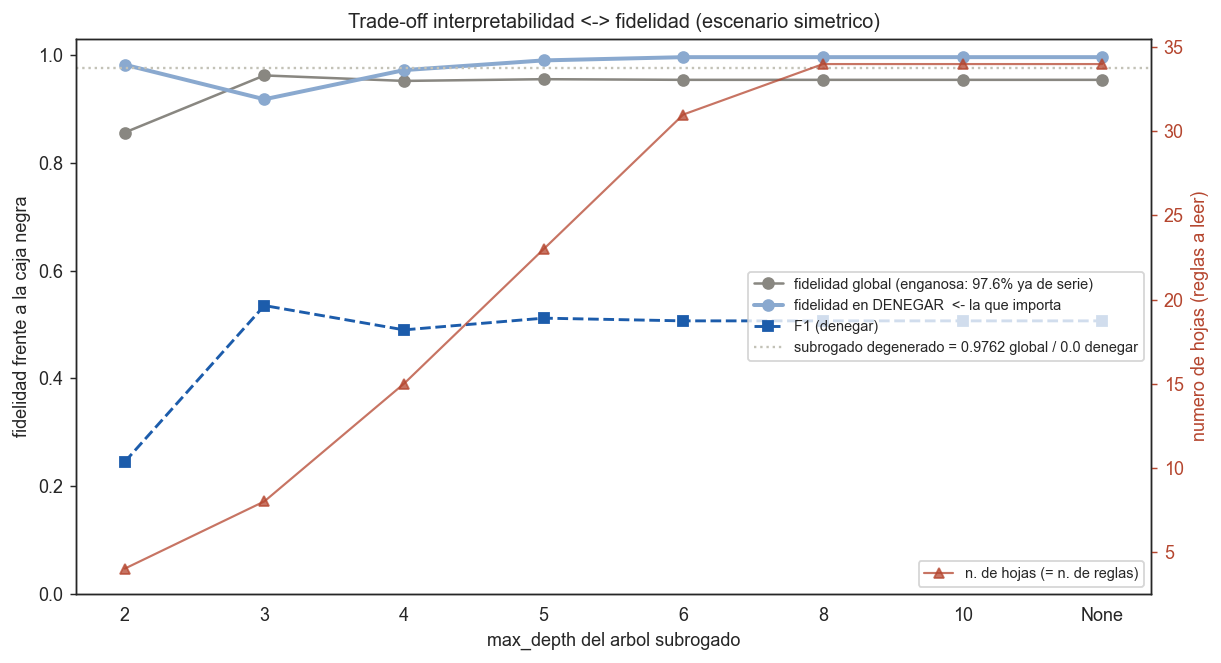

In [3]:
# FIGURA: la curva del trade-off. Dos ejes: fidelidad (izq) y numero de hojas (der).
# El eje de hojas es la medida real de INTERPRETABILIDAD: cada hoja es una regla que un
# humano tendria que leer. 8 reglas se leen; 400 no.
prof_x = [str(p) for p in barrido_c1["max_depth"]]

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.plot(prof_x, barrido_c1["fidelidad_global"], "o-", color=COLOR_MUTED, lw=1.4,
        label="fidelidad global (enganosa: 97.6% ya de serie)")
ax.plot(prof_x, barrido_c1["fid_denegar"], "o-", color=COLOR_ESC1, lw=2.2,
        label="fidelidad en DENEGAR  <- la que importa")
ax.plot(prof_x, barrido_c1["f1_denegar"], "s--", color=COLOR_GANADOR, lw=1.6,
        label="F1 (denegar)")
ax.axhline(met_deg["fidelidad_global"], color=COLOR_BASELINE, ls=":", lw=1.3,
           label=f"subrogado degenerado = {met_deg['fidelidad_global']:.4f} global / 0.0 denegar")
ax.set_xlabel("max_depth del arbol subrogado")
ax.set_ylabel("fidelidad frente a la caja negra")
ax.set_ylim(0, 1.03)
ax.set_title("Trade-off interpretabilidad <-> fidelidad (escenario simetrico)", fontsize=11)
ax.legend(fontsize=8, loc="center right")

# Eje derecho: numero de hojas = numero de reglas = coste de interpretabilidad.
ax2 = ax.twinx()
ax2.plot(prof_x, barrido_c1["n_hojas"], "^-", color=COLOR_ESC2, lw=1.2, alpha=0.75,
         label="n. de hojas (= n. de reglas)")
ax2.set_ylabel("numero de hojas (reglas a leer)", color=COLOR_ESC2)
ax2.tick_params(axis="y", colors=COLOR_ESC2)
ax2.grid(False)
ax2.legend(fontsize=8, loc="lower right")

guardar_figura(fig, "sub_05_fidelidad_vs_profundidad_coste1")

In [4]:
# --- Barrido 2: el efecto de class_weight sobre la CALIDAD de las reglas ---
# El barrido anterior revela un problema: con class_weight="balanced", el subrogado caza casi
# todos los denegados (recall/fid_denegar ~0.98) pero con una precision PESIMA (0.14-0.38), es
# decir, deniega a MUCHA mas gente que la caja negra. Sus reglas describirian un modelo mas
# severo que el real: mala explicacion. Contrastamos tres regimenes de peso.

def barrer_pesos(X, y_bb, profundidades, pesos):
    filas = []
    for peso_nombre, peso in pesos:
        for d in profundidades:
            arbol = DecisionTreeClassifier(
                max_depth=d, class_weight=peso, min_samples_leaf=50,
                random_state=RANDOM_STATE,
            )
            arbol.fit(X, y_bb)
            y_sub = arbol.predict(X)
            met = metricas_fidelidad(y_bb, y_sub)
            met["peso"] = peso_nombre
            met["max_depth"] = d
            met["n_hojas"] = int(arbol.get_n_leaves())
            met["tasa_deny_sub"] = float(y_sub.mean())   # cuanto deniega el ARBOL
            filas.append(met)
    cols = ["peso", "max_depth", "n_hojas", "tasa_deny_sub", "fidelidad_global",
            "fid_denegar", "prec_denegar", "f1_denegar"]
    return pd.DataFrame(filas)[cols]


PESOS = [("balanced", "balanced"), ("sin_peso", None), ("peso_5", {0: 1, 1: 5})]

barrido_pesos_c1 = barrer_pesos(X_test, y_bb_c1, [3, 4, 5, 6], PESOS)

print(f"La CAJA NEGRA deniega al {deny_c1 * 100:.2f}%. Un buen subrogado deberia denegar a una")
print("tasa PARECIDA (columna tasa_deny_sub), no al triple.")
print("=" * 96)
with pd.option_context("display.width", 200, "display.float_format", lambda v: f"{v:.4f}"):
    print(barrido_pesos_c1.to_string(index=False))
print("=" * 96)
print(f"[objetivo] tasa_deny_sub ~ {deny_c1:.4f}   |   f1_denegar lo mas alto posible")

guardar_tabla(barrido_pesos_c1, "sub_05_barrido_pesos_coste1")

La CAJA NEGRA deniega al 2.38%. Un buen subrogado deberia denegar a una
tasa PARECIDA (columna tasa_deny_sub), no al triple.
    peso  max_depth  n_hojas  tasa_deny_sub  fidelidad_global  fid_denegar  prec_denegar  f1_denegar
balanced          3        8         0.0578            0.9621       0.9178        0.3776      0.5350
balanced          4       15         0.0705            0.9519       0.9719        0.3275      0.4899
balanced          5       23         0.0682            0.9551       0.9900        0.3450      0.5117
balanced          6       31         0.0697            0.9539       0.9960        0.3397      0.5066
sin_peso          3        8         0.0159            0.9880       0.5812        0.8709      0.6971
sin_peso          4       12         0.0131            0.9880       0.5230        0.9491      0.6744
sin_peso          5       16         0.0171            0.9887       0.6212        0.8635      0.7226
sin_peso          6       20         0.0171            0.9887      

'results/tables/sub_05_barrido_pesos_coste1.csv'

In [5]:
# 1) El "peso_5" no es magico: barremos el peso finamente para ver la frontera.
pesos_finos = [("sin_peso", None), ("peso_2", {0: 1, 1: 2}), ("peso_3", {0: 1, 1: 3}),
               ("peso_5", {0: 1, 1: 5}), ("peso_8", {0: 1, 1: 8}),
               ("peso_15", {0: 1, 1: 15}), ("balanced", "balanced")]
barrido_fino = barrer_pesos(X_test, y_bb_c1, [5], pesos_finos)
print("Peso de clase vs calidad del subrogado (max_depth=5 fijo)")
print(f"objetivo: tasa_deny_sub ~ {deny_c1:.4f}")
print("=" * 96)
with pd.option_context("display.width", 200, "display.float_format", lambda v: f"{v:.4f}"):
    print(barrido_fino.to_string(index=False))
print("=" * 96)

Peso de clase vs calidad del subrogado (max_depth=5 fijo)
objetivo: tasa_deny_sub ~ 0.0238
    peso  max_depth  n_hojas  tasa_deny_sub  fidelidad_global  fid_denegar  prec_denegar  f1_denegar
sin_peso          5       16         0.0171            0.9887       0.6212        0.8635      0.7226
  peso_2          5       19         0.0277            0.9865       0.7996        0.6856      0.7382
  peso_3          5       23         0.0259            0.9879       0.7896        0.7256      0.7562
  peso_5          5       23         0.0329            0.9842       0.8597        0.6208      0.7210
  peso_8          5       23         0.0474            0.9737       0.9439        0.4734      0.6305
 peso_15          5       23         0.0534            0.9684       0.9599        0.4269      0.5910
balanced          5       23         0.0682            0.9551       0.9900        0.3450      0.5117


In [6]:
# 2) SOBREAJUSTE: hasta ahora entrenamos y evaluamos el subrogado en TEST (21000 filas).
#    Es lo estandar en subrogados (imitamos al modelo donde opera), pero hay que comprobar
#    que las reglas no estan memorizando: partimos test en 2 y medimos fidelidad OUT-OF-SAMPLE.
from sklearn.model_selection import train_test_split

Xa, Xb, ya, yb = train_test_split(X_test, y_bb_c1, test_size=0.5,
                                  stratify=y_bb_c1, random_state=RANDOM_STATE)
arb = DecisionTreeClassifier(max_depth=5, class_weight={0: 1, 1: 5},
                             min_samples_leaf=50, random_state=RANDOM_STATE)
arb.fit(Xa, ya)
met_in = metricas_fidelidad(ya, arb.predict(Xa))
met_out = metricas_fidelidad(yb, arb.predict(Xb))
print("Fidelidad del subrogado (peso_5, depth=5) dentro y fuera de muestra:")
print(f"  IN  (mitad de ajuste)   f1_denegar={met_in['f1_denegar']:.4f}  "
      f"fid_denegar={met_in['fid_denegar']:.4f}  global={met_in['fidelidad_global']:.4f}")
print(f"  OUT (mitad no vista)    f1_denegar={met_out['f1_denegar']:.4f}  "
      f"fid_denegar={met_out['fid_denegar']:.4f}  global={met_out['fidelidad_global']:.4f}")
print()
print("Si el gap IN-OUT es pequeno, las reglas GENERALIZAN: describen la logica de la caja")
print("negra, no memorizan casos concretos de test.")

Fidelidad del subrogado (peso_5, depth=5) dentro y fuera de muestra:
  IN  (mitad de ajuste)   f1_denegar=0.6737  fid_denegar=0.8880  global=0.9795
  OUT (mitad no vista)    f1_denegar=0.6404  fid_denegar=0.8795  global=0.9766

Si el gap IN-OUT es pequeno, las reglas GENERALIZAN: describen la logica de la caja
negra, no memorizan casos concretos de test.


**Hallazgo 2.1 (la fidelidad global es una metrica MENTIROSA aqui):** El resultado mas importante de
esta tabla no es cual es el mejor arbol, sino que **ningun arbol supera al subrogado degenerado en
fidelidad global**:

| subrogado | fidelidad global | fidelidad en DENEGAR |
|---|---|---|
| degenerado ("conceder siempre") | **0.9762** | **0.0000** |
| mejor arbol (`max_depth=3`) | 0.9621 | 0.9178 |

Leido solo por la columna de la izquierda, el veredicto seria demoledor: *el subrogado es PEOR que no
hacer nada*. Y es falso. El arbol de profundidad 3 captura al **92%** de los solicitantes que la caja
negra deniega; el degenerado, al **0%**. La fidelidad global no es que sea poco informativa: es
**activamente enganosa**, porque con solo un 2.38% de denegaciones el 97.6% de la muestra se acierta
sin hacer nada. Esto valida por completo el aviso que dejamos por adelantado en D-5.1, y es la razon
por la que este notebook nunca reporta la fidelidad global sin acompanarla.

**Sobre la forma de la curva.** La fidelidad en denegar NO crece de forma monotona con la
profundidad (0.982 a depth 2, baja a 0.918 a depth 3, sube a 0.996 a depth 6). No es una anomalia:
con `class_weight="balanced"` el arbol persigue la clase minoritaria de forma tan agresiva que el
recall se satura casi de inmediato, y lo que cambia entre profundidades es sobre todo **a costa de
cuanta precision** lo consigue. La precision lo delata: entre 0.14 y 0.38 en todas las
profundidades. Traducido: el arbol deniega a MUCHA mas gente que la caja negra.

**El arbol se satura solo.** A partir de `max_depth=8` la profundidad real deja de crecer (se queda
en 8) y las hojas se estabilizan en 34, aunque quitemos el limite (`max_depth=None`). Lo frena
`min_samples_leaf=50`, que exige que cada regla tenga al menos 50 casos de soporte. El hallazgo de
fondo: **la logica de la caja negra es aproximable con ~34 reglas de soporte razonable**. XGBoost usa
300 arboles, pero la frontera de decision que produce no es tan barroca como su tamano sugiere.

Este diagnostico obliga a revisar `class_weight="balanced"`: si el subrogado deniega al triple que el
modelo real, sus reglas describen un modelo mas severo que el que opera de hecho, y como explicacion
serian **falsas**. La celda siguiente barre el peso de clase para encontrar el punto de equilibrio.

**Hallazgo 2.2 (el peso de clase tiene un OPTIMO INTERIOR, y no es `balanced`):** Barriendo el peso
de la clase "denegar" con `max_depth=5` fijo, el F1 dibuja una curva con maximo claro:

| peso | tasa denegacion del arbol | fid. denegar (cobertura) | precision | F1 |
|---|---|---|---|---|
| sin peso | 0.0171 | 0.6212 | **0.8635** | 0.7226 |
| peso 2 | 0.0277 | 0.7996 | 0.6856 | 0.7382 |
| **peso 3** | **0.0259** | 0.7896 | 0.7256 | **0.7562** |
| peso 5 | 0.0329 | 0.8597 | 0.6208 | 0.7210 |
| peso 8 | 0.0474 | 0.9439 | 0.4734 | 0.6305 |
| `balanced` (~41) | 0.0682 | **0.9900** | 0.3450 | 0.5117 |

*(la caja negra deniega al **0.0238**; ese es el objetivo de la segunda columna)*

El trade-off es nitido y va en la direccion esperada: **a mas peso, mas cobertura y menos
precision**. Los dos extremos fallan por motivos OPUESTOS:

- **Sin reponderar** el arbol es *timido*: cuando deniega acierta casi siempre (precision 0.86) pero
  se deja fuera al **38%** de las denegaciones reales. Sus reglas serian ciertas pero INCOMPLETAS:
  explicarian solo dos tercios de los rechazos.
- **`balanced`** (que equivale a un peso de ~41, dado el desbalanceo 2.38/97.62) es *paranoico*:
  captura el 99% de las denegaciones, pero denegando al **6.8%** de la muestra -casi el triple que la
  caja negra- y con una precision de 0.35. De cada 3 personas a las que este arbol deniega, 2
  obtendrian el credito en realidad. Sus reglas describirian un modelo mas severo que el real: como
  explicacion, **mienten**.

**Eleccion: `peso = 3`.** Maximiza el F1 (0.7562) y ademas su tasa de denegacion (2.59%) es la que
mas se aproxima a la de la caja negra (2.38%), lo cual es un criterio de sanidad independiente del
F1: un buen imitador deniega a tanta gente como el imitado. Que el optimo sea interior -y no un
extremo- confirma que ni la opcion ingenua (no tocar nada) ni la opcion por defecto (`balanced`) eran
adecuadas. Esto **cierra D-5.1** en su parte de reponderacion.

**Eleccion: `max_depth = 5`.** El arbol se satura ahi (depth 5 y depth 6 dan metricas IDENTICAS con
`peso_5`), asi que no es una eleccion arbitraria: es el punto donde la curva se aplana. Da **23
hojas**, es decir, 23 reglas. Se conserva ademas un **subrogado de bolsillo** con `max_depth=3` (8
hojas, F1 0.676): pierde poca fidelidad y es el unico que un humano puede leer de un vistazo, asi que
sera el que usemos en la seccion 6 para responder a la pregunta del enunciado ("si un cliente pide
explicaciones, que informacion le damos?"). El operativo (23 reglas) audita; el comunicable (8
reglas) explica.

**Las reglas GENERALIZAN (no memorizan):** ajustando el subrogado sobre la mitad de test y midiendo
en la mitad no vista, el gap es despreciable:

| | F1 (denegar) | fidelidad denegar | fidelidad global |
|---|---|---|---|
| dentro de muestra | 0.6737 | 0.8880 | 0.9795 |
| **fuera de muestra** | **0.6404** | **0.8795** | **0.9766** |

Un gap de 0.033 en F1 y 0.009 en cobertura. El subrogado no esta memorizando casos concretos del
conjunto de test: esta capturando la **logica** de la caja negra, que es justo lo que un explicador
debe hacer. (Los valores absolutos son algo menores que en la tabla principal porque este arbol se
ajusta con la mitad de los datos, 10500 filas en vez de 21000; lo relevante es el GAP, no el nivel.)

**Nota metodologica.** Ajustar y evaluar el subrogado sobre el mismo conjunto (test) es el patron
estandar en modelos subrogados, y no constituye fuga: no estamos seleccionando hiperparametros del
modelo principal -que esta cerrado desde `03`/`04`- sino DESCRIBIENDO su comportamiento sobre la
muestra donde opera. Aun asi, la comprobacion in/out de arriba deja documentado que las reglas
resisten fuera de muestra.

In [7]:
# --- Subrogado DEFINITIVO del escenario simetrico ---
# Fijados por el barrido: peso de clase = 3 (optimo del F1), max_depth = 5 (operativo, se audita)
# y max_depth = 3 (de bolsillo, para explicar al cliente en la seccion 6). min_samples_leaf=50
# garantiza que cada regla tenga soporte (>=50 casos), no anecdotas.
PESO_DENEGAR = {0: 1, 1: 3}
MIN_HOJA = 50

sub_c1 = DecisionTreeClassifier(max_depth=5, class_weight=PESO_DENEGAR,
                                min_samples_leaf=MIN_HOJA, random_state=RANDOM_STATE)
sub_c1.fit(X_test, y_bb_c1)                          # OBJETIVO = decisiones de la caja negra

sub_c1_bolsillo = DecisionTreeClassifier(max_depth=3, class_weight=PESO_DENEGAR,
                                         min_samples_leaf=MIN_HOJA, random_state=RANDOM_STATE)
sub_c1_bolsillo.fit(X_test, y_bb_c1)

met_c1 = metricas_fidelidad(y_bb_c1, sub_c1.predict(X_test))
met_c1_bols = metricas_fidelidad(y_bb_c1, sub_c1_bolsillo.predict(X_test))

print("SUBROGADO DEFINITIVO - escenario simetrico (coste1)")
print(f"  operativo  (depth=5): {sub_c1.get_n_leaves()} hojas | "
      f"F1={met_c1['f1_denegar']:.4f} | fid_denegar={met_c1['fid_denegar']:.4f} | "
      f"global={met_c1['fidelidad_global']:.4f}")
print(f"  bolsillo   (depth=3): {sub_c1_bolsillo.get_n_leaves()} hojas | "
      f"F1={met_c1_bols['f1_denegar']:.4f} | fid_denegar={met_c1_bols['fid_denegar']:.4f} | "
      f"global={met_c1_bols['fidelidad_global']:.4f}")

SUBROGADO DEFINITIVO - escenario simetrico (coste1)
  operativo  (depth=5): 23 hojas | F1=0.7562 | fid_denegar=0.7896 | global=0.9879
  bolsillo   (depth=3): 8 hojas | F1=0.6758 | fid_denegar=0.8397 | global=0.9809


## 3. Ajuste del arbol subrogado para el escenario coste10 (asimetrico)

Analogo a la seccion 2, pero el objetivo es `y_bb_c10`: las decisiones de la MISMA caja negra bajo el
umbral asimetrico (0.0906). Recordatorio de D-0.2: no es otro modelo, es el mismo scoring con el
corte mas bajo, asi que aqui XGBoost deniega al **18.70%** en vez del 2.38%.

**Por que esperamos un subrogado MEJOR aqui.** El problema de la seccion 2 era el desbalanceo
extremo (2.38% de denegaciones): la clase a explicar era una aguja en un pajar. En el asimetrico la
clase "denegar" es casi 8 veces mas frecuente, asi que el arbol tiene muchos mas ejemplos de rechazo
de los que aprender, y el subrogado degenerado deja de ser una amenaza (tendria 81.3% de fidelidad
global, no 97.6%). Anticipamos: mejor F1, peso de clase optimo mas cercano a 1, y reglas mas
fiables. Lo verificamos con el mismo barrido, para no asumirlo.

Repetimos por tanto el mismo protocolo (barrido de peso a `max_depth=5`, eleccion por F1, arbol
operativo + de bolsillo), de forma que los dos escenarios sean comparables regla a regla en la
seccion 6.

In [8]:
# --- Mismo barrido de peso, ahora sobre el objetivo asimetrico y_bb_c10 ---
# La caja negra deniega al 18.70%: desbalanceo mucho mas suave. Esperamos peso optimo bajo.
barrido_pesos_c10 = barrer_pesos(X_test, y_bb_c10, [3, 4, 5, 6],
                                 [("sin_peso", None), ("peso_2", {0: 1, 1: 2}),
                                  ("peso_3", {0: 1, 1: 3}), ("balanced", "balanced")])

deg_c10 = metricas_fidelidad(y_bb_c10, np.zeros_like(y_bb_c10))

print(f"BARRIDO DE PESO - escenario coste10 (asimetrico, la caja negra deniega al "
      f"{deny_c10 * 100:.2f}%)")
print(f"objetivo: tasa_deny_sub ~ {deny_c10:.4f}")
print("=" * 96)
with pd.option_context("display.width", 200, "display.float_format", lambda v: f"{v:.4f}"):
    print(barrido_pesos_c10.to_string(index=False))
print("=" * 96)
print(f"[REFERENCIA] subrogado degenerado: global={deg_c10['fidelidad_global']:.4f}  "
      f"fid_denegar={deg_c10['fid_denegar']:.4f}")

guardar_tabla(barrido_pesos_c10, "sub_05_barrido_pesos_coste10")

BARRIDO DE PESO - escenario coste10 (asimetrico, la caja negra deniega al 18.70%)
objetivo: tasa_deny_sub ~ 0.1870
    peso  max_depth  n_hojas  tasa_deny_sub  fidelidad_global  fid_denegar  prec_denegar  f1_denegar
sin_peso          3        8         0.1196            0.9173       0.5988        0.9359      0.7304
sin_peso          4       15         0.2092            0.9289       0.8693        0.7769      0.8205
sin_peso          5       23         0.1876            0.9415       0.8454        0.8424      0.8439
sin_peso          6       32         0.1706            0.9467       0.8138        0.8917      0.8510
  peso_2          3        8         0.2158            0.9110       0.8393        0.7271      0.7791
  peso_2          4       16         0.2129            0.9270       0.8742        0.7676      0.8174
  peso_2          5       26         0.2129            0.9336       0.8917        0.7830      0.8339
  peso_2          6       39         0.2085            0.9370       0.8892   

'results/tables/sub_05_barrido_pesos_coste10.csv'

**Hallazgo 3.1 (el subrogado asimetrico es mejor):** El contraste
entre los dos escenarios es el resultado central de este notebook:

| escenario | deniega la caja negra | mejor F1 subrogado | peso optimo |
|---|---|---|---|
| simetrico (`coste1`) | 2.38% | 0.756 | 3 |
| asimetrico (`coste10`) | 18.70% | **0.844** | **sin peso** |

El subrogado del asimetrico imita a la MISMA caja negra bastante mejor. La causa no es el modelo
-es el mismo XGBoost- sino la FRECUENCIA de la clase a explicar: en el simetrico "denegar" era una
aguja en un pajar (2.38%), y explicar un evento raro con reglas es intrinsecamente dificil; en el
asimetrico la clase es 8 veces mas frecuente, el arbol dispone de muchos mas ejemplos de rechazo, y
sus reglas salen mas fieles. **Leccion general: cuanto mas rara es la decision que se quiere
explicar, mas cuesta explicarla**, aunque el modelo subyacente sea identico.

**Aqui NO se repondera (contraste con la seccion 2).** El barrido muestra que el peso optimo es
`sin_peso`: con `max_depth=5` da F1 0.8439 y, lo mas revelador, **deniega al 18.76% cuando la caja
negra deniega al 18.70%** -practicamente identico- sin ninguna reponderacion. Subir el peso solo
degrada la precision (con `balanced` cae a 0.71) sin ganar F1. Esto cierra de forma limpia la
discusion de D-5.1: la reponderacion NO es una decision de diseno fija, es una respuesta al
desbalanceo. Cuando la clase es rara (esc. simetrico) hace falta peso 3; cuando es frecuente (esc.
asimetrico) el arbol replica la decision de forma natural y reponderar sobra. El mismo protocolo da
respuestas distintas segun los datos, que es como debe ser.

**Profundidad 5, por coherencia y por saturacion.** `max_depth=6` daria un F1 marginalmente superior
(0.851) a costa de 32 hojas frente a 23 y peor cobertura. Se fija `max_depth=5` -igual que en el
simetrico- para que los dos arboles sean comparables regla a regla en la seccion 6. Se conserva el
subrogado de bolsillo (`max_depth=3`, 8 hojas) para la explicacion al cliente.

**El degenerado ya no engana.** A diferencia del simetrico (donde ningun arbol batia al degenerado en
fidelidad global), aqui el subrogado la supera con holgura: 0.9415 frente a 0.8130. Es la
confirmacion final de que el problema de la seccion 2 era estrictamente el desbalanceo, no el metodo
subrogado.

In [9]:
# --- Subrogado DEFINITIVO del escenario asimetrico ---
# Fijados por el barrido: SIN reponderar (replica la tasa de la caja negra de forma natural),
# depth=5 operativo + depth=3 de bolsillo. Mismo min_samples_leaf que el simetrico.
sub_c10 = DecisionTreeClassifier(max_depth=5, class_weight=None,
                                 min_samples_leaf=MIN_HOJA, random_state=RANDOM_STATE)
sub_c10.fit(X_test, y_bb_c10)

sub_c10_bolsillo = DecisionTreeClassifier(max_depth=3, class_weight=None,
                                          min_samples_leaf=MIN_HOJA, random_state=RANDOM_STATE)
sub_c10_bolsillo.fit(X_test, y_bb_c10)

met_c10 = metricas_fidelidad(y_bb_c10, sub_c10.predict(X_test))
met_c10_bols = metricas_fidelidad(y_bb_c10, sub_c10_bolsillo.predict(X_test))

print("SUBROGADO DEFINITIVO - escenario asimetrico (coste10)")
print(f"  operativo  (depth=5): {sub_c10.get_n_leaves()} hojas | "
      f"F1={met_c10['f1_denegar']:.4f} | fid_denegar={met_c10['fid_denegar']:.4f} | "
      f"global={met_c10['fidelidad_global']:.4f}")
print(f"  bolsillo   (depth=3): {sub_c10_bolsillo.get_n_leaves()} hojas | "
      f"F1={met_c10_bols['f1_denegar']:.4f} | fid_denegar={met_c10_bols['fid_denegar']:.4f} | "
      f"global={met_c10_bols['fidelidad_global']:.4f}")

SUBROGADO DEFINITIVO - escenario asimetrico (coste10)
  operativo  (depth=5): 23 hojas | F1=0.8439 | fid_denegar=0.8454 | global=0.9415
  bolsillo   (depth=3): 8 hojas | F1=0.7304 | fid_denegar=0.5988 | global=0.9173


**Hallazgo 3.2 (el limite del subrogado de bolsillo es la PROFUNDIDAD, no el soporte):** El arbol de
bolsillo asimetrico (`max_depth=3`) captura solo el **60%** de las denegaciones de la caja negra
(`fid_denegar=0.5988`), frente al 84% que alcanzaba el bolsillo simetrico. Cabria pensar que se
mejora abriendo ramas mas finas (bajando `min_samples_leaf`), pero el barrido muestra que **no cambia
absolutamente nada**: de `min_samples_leaf=50` a 10, el arbol da siempre 8 hojas y las mismas
metricas. La razon es estructural: con profundidad 3 el arbol ya usa sus 2^3 = 8 hojas maximas, asi
que el cuello de botella no es el soporte de las hojas sino la profundidad. **0.60 es el techo real
de una explicacion de 8 reglas en este escenario.** No es una eleccion conservadora que se pueda
relajar; es la frontera de lo que 8 condiciones pueden describir. Para mas cobertura solo hay dos
salidas, ambas descartadas: subir la profundidad (y entonces deja de ser "de bolsillo": es el
operativo de 23 reglas, que llega al 85%) o reponderar (que dispara la tasa de denegacion muy por
encima de la de la caja negra, ver Hallazgo 3.1). Que el bolsillo cubra menos en el asimetrico que en
el simetrico es a su vez informativo: cuando el banco deniega a mas gente y por mas motivos, resumir
el "por que" en 8 reglas cuesta mas.

## 4. Extraccion de reglas legibles

Volcamos cada arbol subrogado a un formato que un humano pueda leer, y ahi aparece por fin la
respuesta a la pregunta del enunciado: "si un cliente pide explicaciones sobre por que se le deniega
un credito, que informacion le damos?". Producimos tres artefactos por escenario:

1. **Reglas en texto** (`export_text`), con los umbrales traducidos de la escala estandarizada a la
   escala ORIGINAL (euros, anios, ratios). Sin esta traduccion las reglas dirian "age <= -0.73",
   ilegible; con ella dicen "edad <= 41 anios". La traduccion deshace toda la cadena de preprocesado
   (StandardScaler + log1p + winsorizacion) via `inverse_transform` del pipeline del `02`.
2. **Figura del arbol** (`plot_tree`), entregable `arbol_subrogado_coste{1,10}.png`.
3. **Fichero de reglas de DENEGACION** destiladas, entregable `reglas_subrogado_coste{1,10}.md`: solo
   las ramas que terminan en "denegar", que son las que hay que poder justificar ante un cliente.

Mostramos el arbol de BOLSILLO (`max_depth=3`, 8 reglas) por su legibilidad; el operativo
(`max_depth=5`, 23 reglas) se guarda completo en los ficheros pero no se imprime en linea (seria
ilegible en pantalla).

In [17]:
# --- Traductor de umbrales: escala estandarizada -> escala original (euros/anios/ratios) ---
# Un umbral del arbol viene en la escala del StandardScaler. Para leerlo, lo colocamos en la
# columna correspondiente de una fila neutra y aplicamos inverse_transform del pipeline del 02,
# que deshace TODA la cadena (scaler + log1p + winsorizacion). Validado: std=0 recupera ~mediana.
pipeline = joblib.load("results/models/preprocessing_pipeline.joblib")
COLS_SALIDA = list(pipeline.columnas_salida_)

def umbral_a_original(feature, umbral_std):
    """Convierte un umbral en escala estandarizada a la escala original legible."""
    fila = pd.DataFrame(np.zeros((1, len(COLS_SALIDA))), columns=COLS_SALIDA)
    fila[feature] = umbral_std
    orig = pipeline.inverse_transform(fila)
    return float(np.asarray(orig[feature])[0])

In [20]:
# --- Generador de reglas legibles: umbrales traducidos + formato entero/decimal por tipo ---
# Los contadores de impago/creditos son ENTEROS: un corte traducido a 2.50 significa ">=3".
# Las continuas (utilizacion, ratio, ingresos, edad) se dejan con decimales. Distinguimos por
# lista explicita para que el .md entregable se lea como lo leeria un analista de riesgos.
import re

# Features de conteo (enteras): sus umbrales se redondean y se expresan como ">= N" / "<= N".
FEATURES_CONTEO = {
    "NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse", "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines", "NumberOfDependents",
}
# Nombres legibles en castellano para el entregable.
NOMBRE_LEGIBLE = {
    "RevolvingUtilizationOfUnsecuredLines": "Utilizacion de credito revolving",
    "age": "Edad",
    "NumberOfTime30-59DaysPastDueNotWorse": "N. moras 30-59 dias",
    "DebtRatio": "Ratio de deuda",
    "MonthlyIncome": "Ingreso mensual",
    "NumberOfOpenCreditLinesAndLoans": "N. lineas de credito abiertas",
    "NumberOfTimes90DaysLate": "N. impagos 90+ dias",
    "NumberRealEstateLoansOrLines": "N. hipotecas/lineas inmob.",
    "NumberOfTime60-89DaysPastDueNotWorse": "N. moras 60-89 dias",
    "NumberOfDependents": "N. dependientes",
    "is_missing_monthlyincome": "Ingreso ausente (flag)",
    "es_centinela_pastdue": "Centinela mora (flag)",
}


def _fmt_umbral(feature, umbral_std, operador):
    """Traduce un umbral estandarizado a escala original y lo formatea segun el tipo de feature.

    Para contadores enteros: 'feature <= 0.50' (std) -> '0 impagos'; '> 2.50' -> '>= 3'.
    Para continuas: valor con 2 decimales.
    """
    val = umbral_a_original(feature, umbral_std)
    nombre = NOMBRE_LEGIBLE.get(feature, feature)
    if feature in FEATURES_CONTEO:
        # El corte cae entre enteros (p.ej. 2.50 separa 2 de 3).
        if operador == "<=":
            n = int(np.floor(val + 0.5))        # "<= 2.50" -> "<= 2"
            return f"{nombre} <= {n}"
        else:
            n = int(np.floor(val + 0.5)) + 1    # "> 2.50" -> ">= 3"
            return f"{nombre} >= {n}"
    else:
        simbolo = "<=" if operador == "<=" else ">"
        return f"{nombre} {simbolo} {val:.2f}"


def reglas_legibles(arbol, cols):
    """Devuelve el texto del arbol con umbrales traducidos y nombres/formatos legibles."""
    txt = export_text(arbol, feature_names=list(cols),
                      class_names=["CONCEDER", "DENEGAR"], show_weights=False)
    # export_text imprime 'feature <= valor' o 'feature >  valor' (escala std).
    patron = re.compile(r"([\w\-]+)\s*(<=|>)\s*(-?\d+\.?\d*)")

    def _sub(m):
        return _fmt_umbral(m.group(1), float(m.group(3)), m.group(2))

    return "\n".join(patron.sub(_sub, l) for l in txt.splitlines())


# Prueba sobre el bolsillo simetrico (el que ya conocemos, para verificar el formato).
print("=" * 74)
print("SUBROGADO DE BOLSILLO - escenario SIMETRICO (coste1), reglas legibles")
print("Imita: decisiones de XGBoost bajo umbral 0.4934 (deniega al 2.38%)")
print("=" * 74)
print(reglas_legibles(sub_c1_bolsillo, X_test.columns))

SUBROGADO DE BOLSILLO - escenario SIMETRICO (coste1), reglas legibles
Imita: decisiones de XGBoost bajo umbral 0.4934 (deniega al 2.38%)
|--- N. impagos 90+ dias <= 1
|   |--- N. moras 30-59 dias <= 2
|   |   |--- N. lineas de credito abiertas <= 0
|   |   |   |--- class: CONCEDER
|   |   |--- N. lineas de credito abiertas >= 1
|   |   |   |--- class: CONCEDER
|   |--- N. moras 30-59 dias >= 3
|   |   |--- Utilizacion de credito revolving <= 0.73
|   |   |   |--- class: CONCEDER
|   |   |--- Utilizacion de credito revolving > 0.73
|   |   |   |--- class: DENEGAR
|--- N. impagos 90+ dias >= 2
|   |--- N. moras 60-89 dias <= 1
|   |   |--- N. impagos 90+ dias <= 2
|   |   |   |--- class: CONCEDER
|   |   |--- N. impagos 90+ dias >= 3
|   |   |   |--- class: DENEGAR
|   |--- N. moras 60-89 dias >= 2
|   |   |--- N. impagos 90+ dias <= 2
|   |   |   |--- class: DENEGAR
|   |   |--- N. impagos 90+ dias >= 3
|   |   |   |--- class: DENEGAR


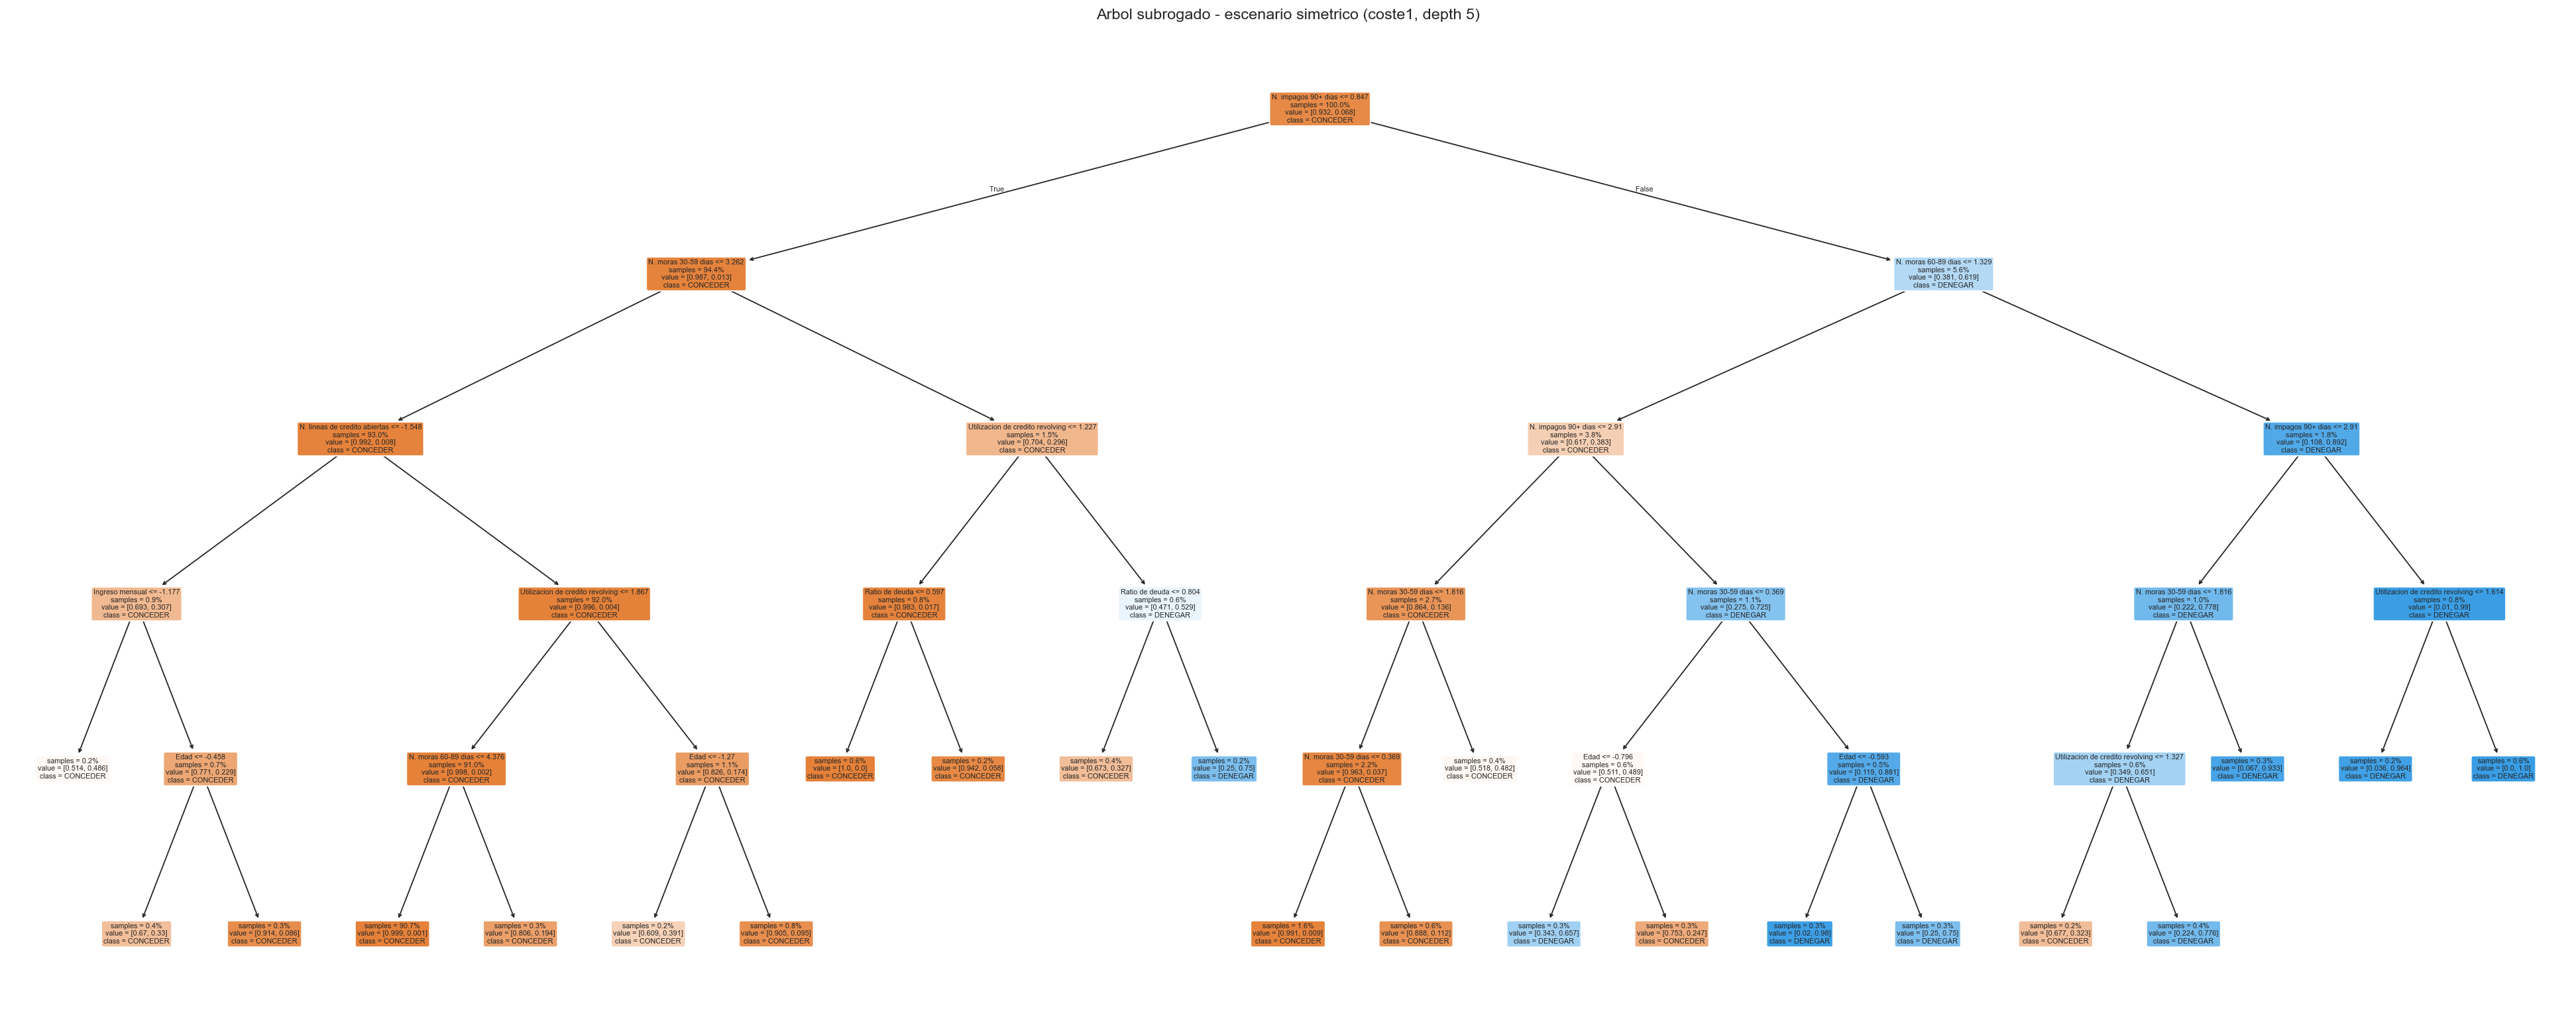

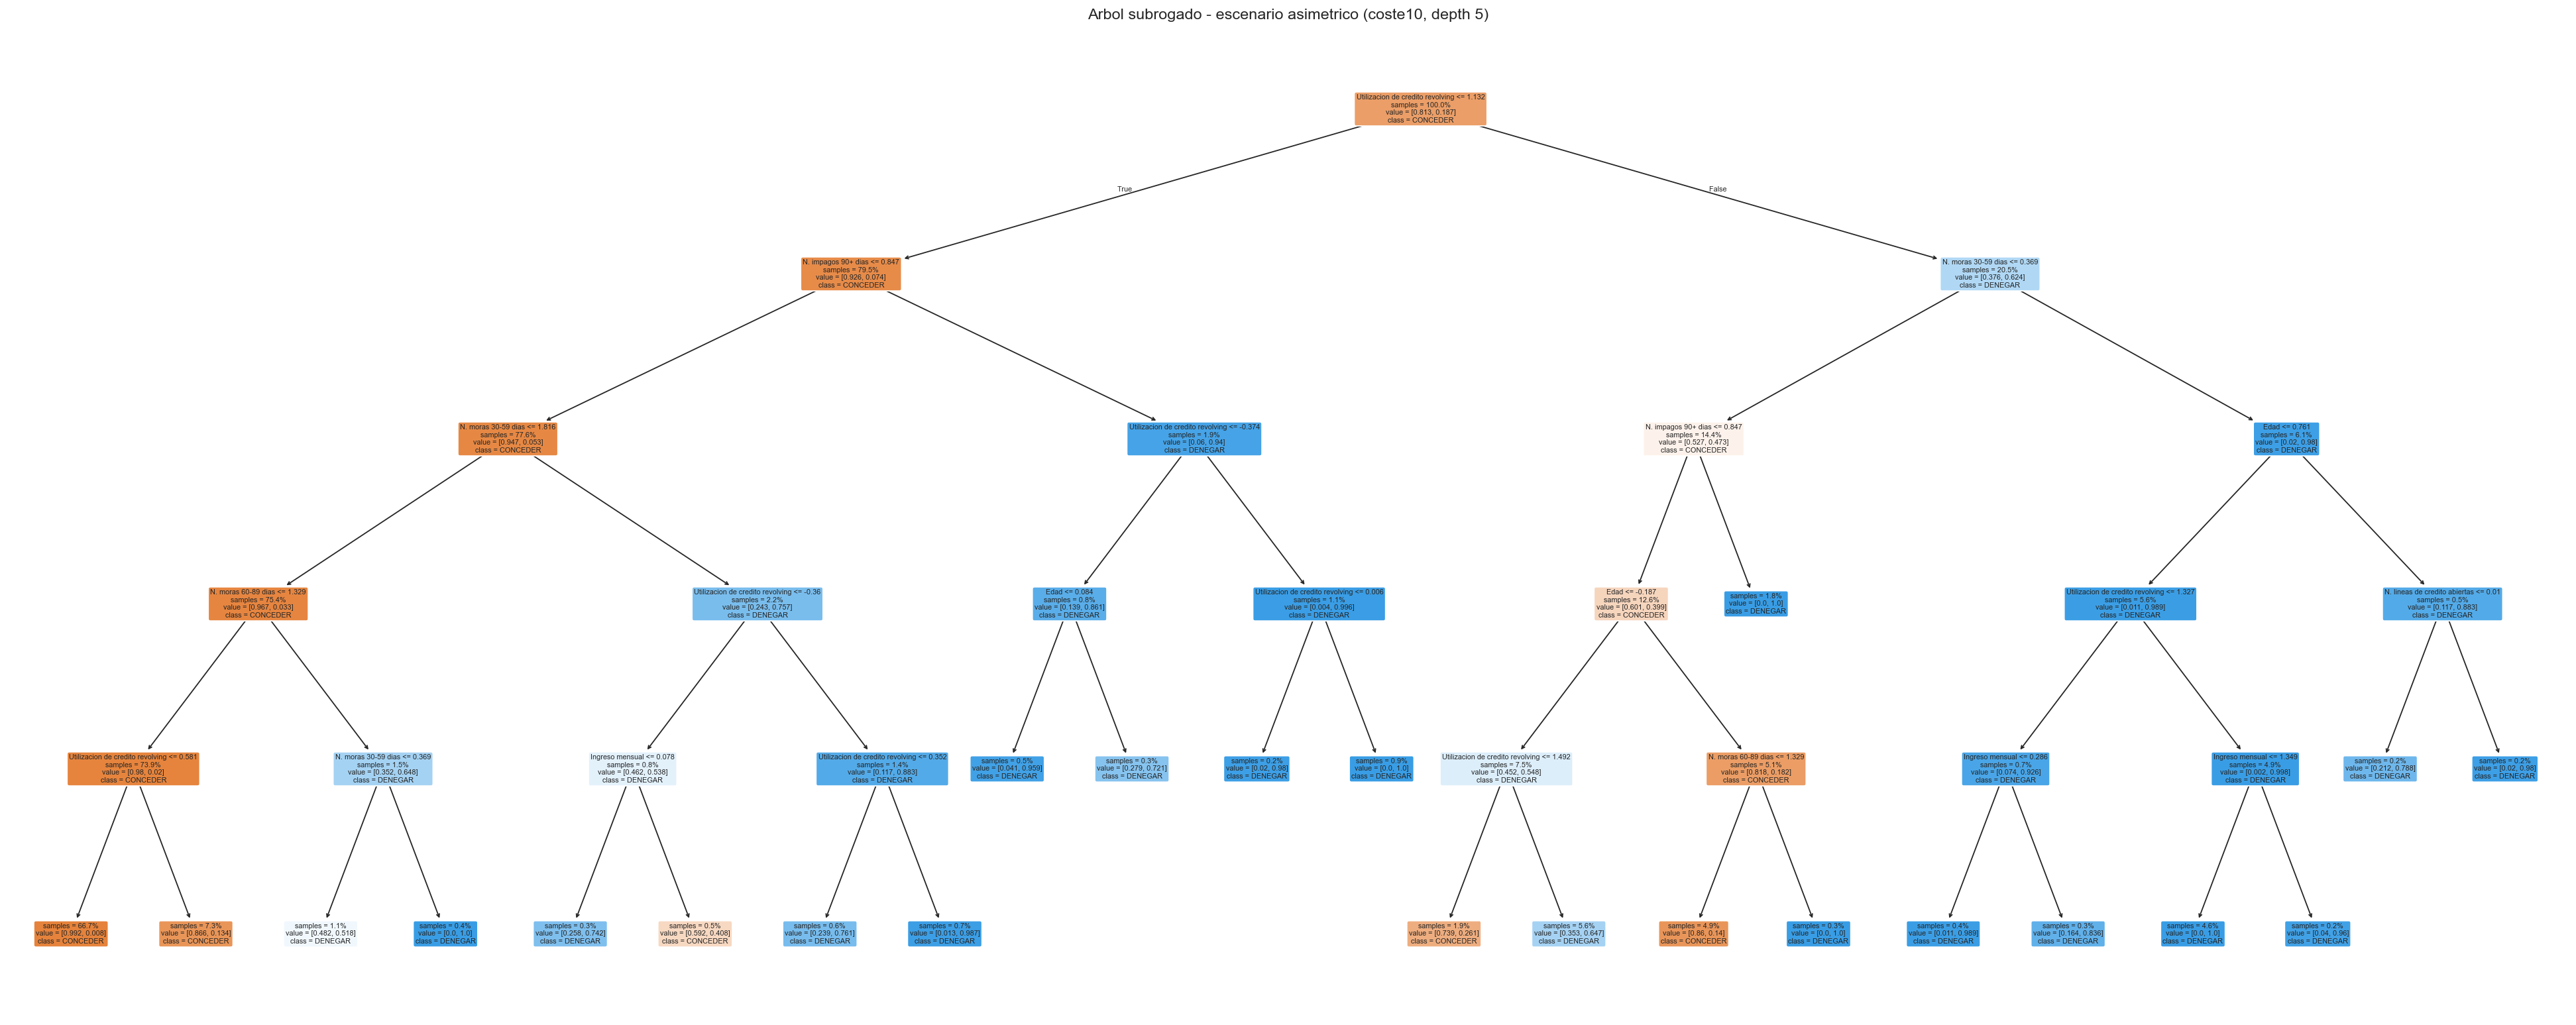

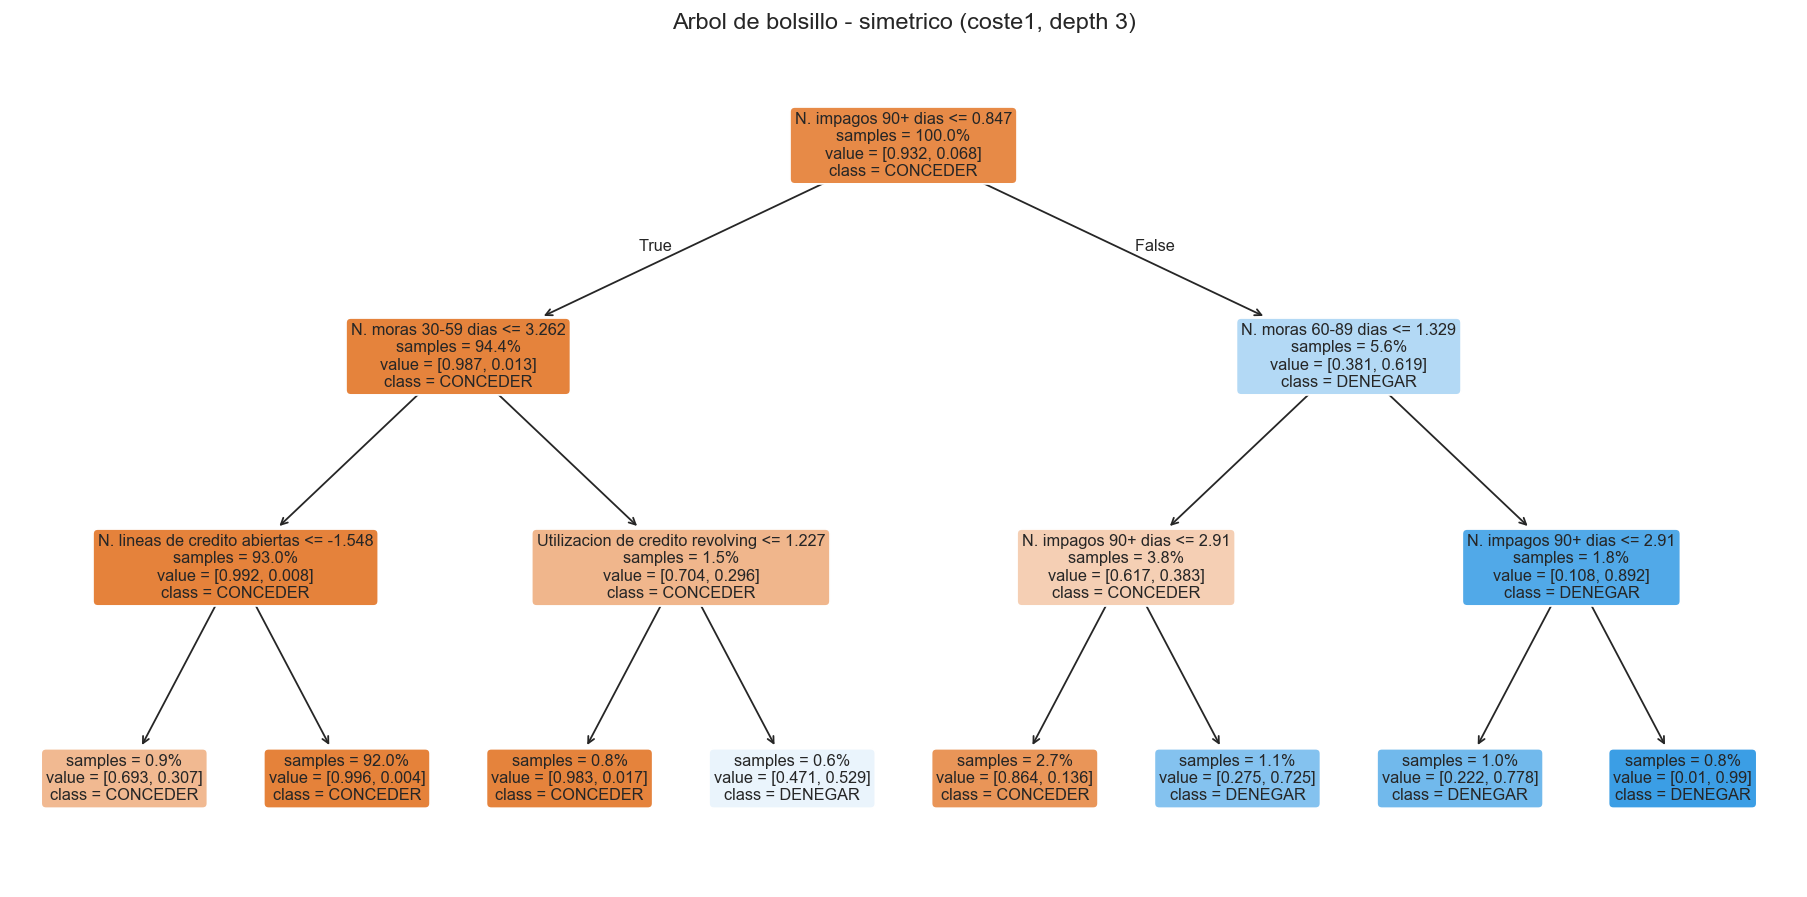

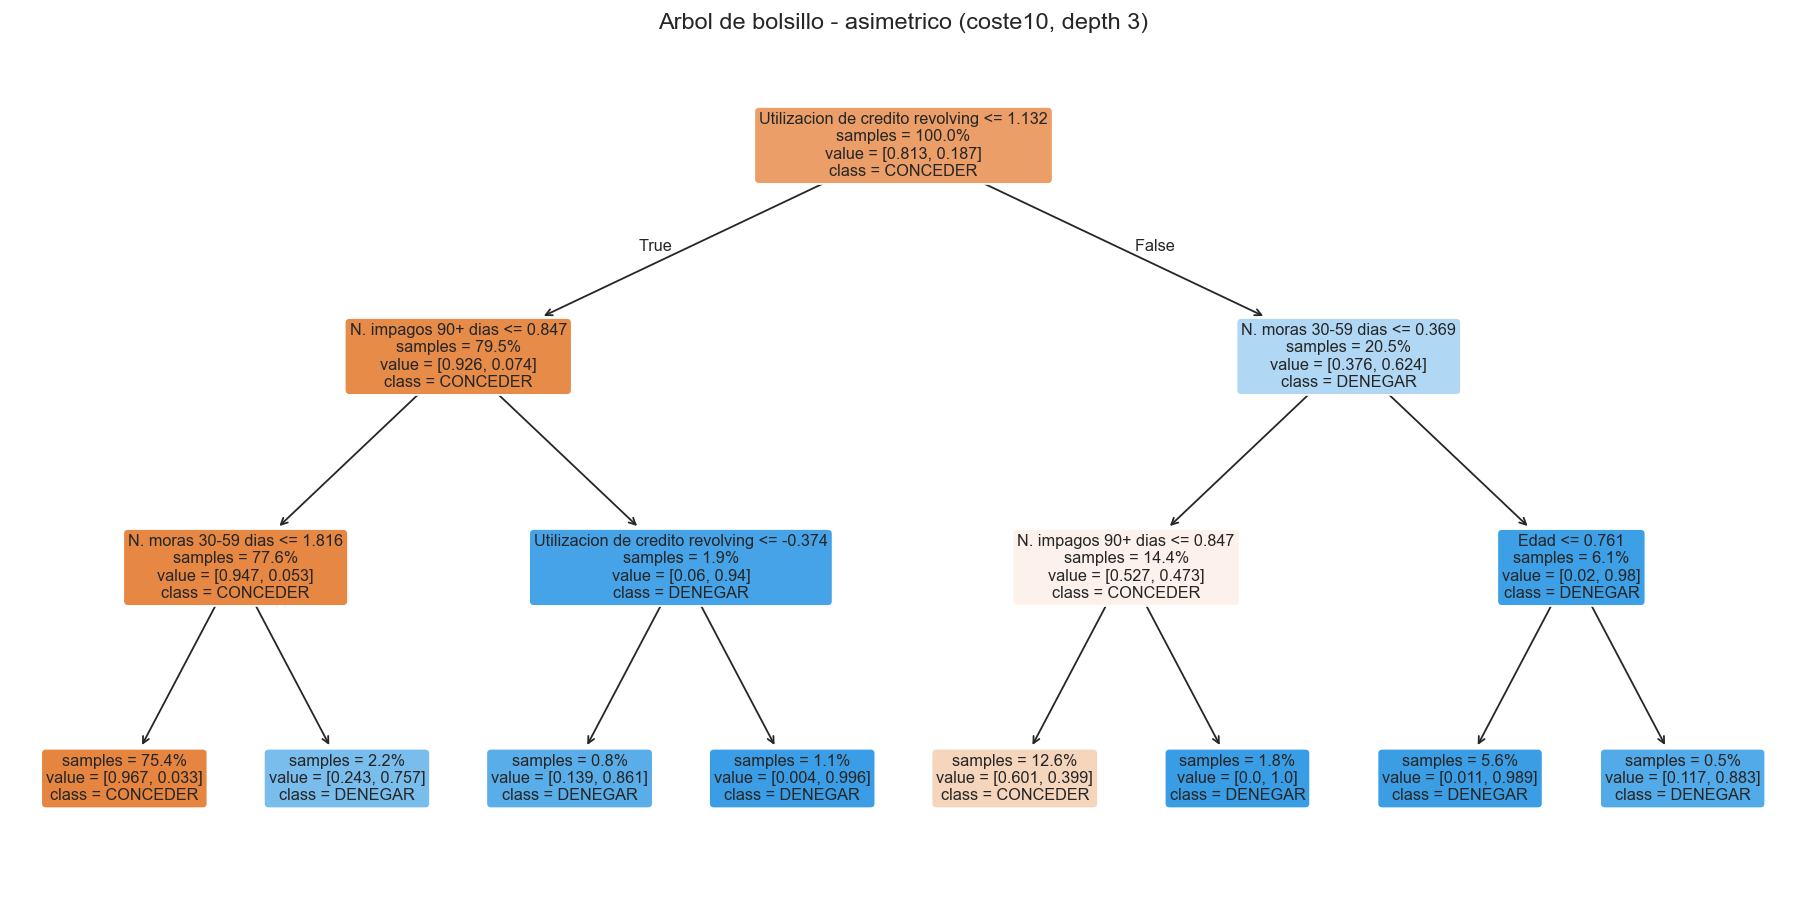

4 figuras guardadas en results/figures/:
  arbol_subrogado_coste1.png / arbol_subrogado_coste10.png  (ENTREGABLES, depth 5)
  sub_05_arbol_bolsillo_coste1.png / _coste10.png            (apoyo, depth 3)


In [24]:
# --- Figuras de los arboles subrogados (plot_tree) ---
# Entregables: arbol_subrogado_coste1.png y arbol_subrogado_coste10.png (los OPERATIVOS, depth 5).
# Los operativos tienen 23 hojas: necesitan lienzo ancho y fuente pequena para no solaparse.
# El .md que generamos despues traduce los umbrales a euros/anios; la figura da la ESTRUCTURA.
NOMBRES_FIG = [NOMBRE_LEGIBLE.get(c, c) for c in X_test.columns]

def dibujar_arbol(arbol, titulo, nombre_fichero, figsize, fontsize):
    fig, ax = plt.subplots(figsize=figsize)
    plot_tree(arbol, feature_names=NOMBRES_FIG, class_names=["CONCEDER", "DENEGAR"],
              filled=True, rounded=True, fontsize=fontsize, impurity=False,
              proportion=True, ax=ax)
    ax.set_title(titulo, fontsize=13)
    guardar_figura(fig, nombre_fichero)

# Operativos (depth 5, 23 hojas): ENTREGABLES. Lienzo MUCHO mas ancho + fuente 6.
dibujar_arbol(sub_c1, "Arbol subrogado - escenario simetrico (coste1, depth 5)",
              "arbol_subrogado_coste1", (30, 12), 6)
dibujar_arbol(sub_c10, "Arbol subrogado - escenario asimetrico (coste10, depth 5)",
              "arbol_subrogado_coste10", (30, 12), 6)

# De bolsillo (depth 3, 8 hojas): apoyo visual para la seccion 6.
dibujar_arbol(sub_c1_bolsillo, "Arbol de bolsillo - simetrico (coste1, depth 3)",
              "sub_05_arbol_bolsillo_coste1", (14, 7), 9)
dibujar_arbol(sub_c10_bolsillo, "Arbol de bolsillo - asimetrico (coste10, depth 3)",
              "sub_05_arbol_bolsillo_coste10", (14, 7), 9)

print("4 figuras guardadas en results/figures/:")
print("  arbol_subrogado_coste1.png / arbol_subrogado_coste10.png  (ENTREGABLES, depth 5)")
print("  sub_05_arbol_bolsillo_coste1.png / _coste10.png            (apoyo, depth 3)")

In [28]:
# --- Ficheros .md de reglas de DENEGACION (entregables del notebook) ---
# reglas_subrogado_coste1.md y reglas_subrogado_coste10.md: extraen SOLO las ramas que terminan
# en "denegar" del arbol OPERATIVO (depth 5), con umbrales en escala real y el soporte de cada
# regla. Cuando una feature aparece varias veces en una rama (el arbol la parte a distintos
# niveles), se CONSOLIDAN sus cortes en un unico intervalo, para que la regla no repita variables.

def _valor_legible(feature, umbral_std, operador):
    """Valor numerico traducido (sin nombre), para construir intervalos consolidados."""
    val = umbral_a_original(feature, umbral_std)
    if feature in FEATURES_CONTEO:
        return int(np.floor(val + 0.5)) + (1 if operador == ">" else 0)
    return round(val, 2)


def _consolidar(cortes):
    """Convierte {feature: [low, high]} (escala std) en condiciones legibles, una por feature."""
    condiciones = []
    for f, (low, high) in cortes.items():
        tiene_low = low > -np.inf
        tiene_high = high < np.inf
        nombre = NOMBRE_LEGIBLE.get(f, f)
        if tiene_low and tiene_high:
            lo = _valor_legible(f, low, ">")
            hi = _valor_legible(f, high, "<=")
            if f in FEATURES_CONTEO and (hi - lo) <= 1:
                condiciones.append(f"{nombre} = {int(round(hi))}")
            else:
                condiciones.append(f"{nombre}: entre {lo} y {hi}")
        elif tiene_high:
            condiciones.append(_fmt_umbral(f, high, "<="))
        elif tiene_low:
            condiciones.append(_fmt_umbral(f, low, ">"))
    return condiciones


def extraer_reglas_denegacion(arbol, cols):
    """Ramas hoja->DENEGAR con las condiciones CONSOLIDADAS por variable.

    Si una feature aparece varias veces en una rama, se combinan sus cortes en un unico
    intervalo [low, high] (escala estandarizada) y se imprime una sola condicion legible.
    pureza = fraccion de la hoja que la caja negra tambien deniega (fidelidad local).
    """
    t = arbol.tree_
    cols = list(cols)
    reglas = []

    def recorrer(nodo, cortes):
        es_hoja = t.children_left[nodo] == t.children_right[nodo]
        if es_hoja:
            clase = int(np.argmax(t.value[nodo][0]))
            if clase == 1:                                    # 1 = DENEGAR
                reglas.append({
                    "condiciones": _consolidar(cortes),
                    "soporte": int(t.n_node_samples[nodo]),
                    "pureza": float(t.value[nodo][0][1] / t.value[nodo][0].sum()),
                })
            return
        f = cols[t.feature[nodo]]
        u = float(t.threshold[nodo])

        # izquierda: f <= u  (baja el techo)
        izq = {k: list(v) for k, v in cortes.items()}
        low, high = izq.get(f, [-np.inf, np.inf])
        izq[f] = [low, min(high, u)]
        recorrer(t.children_left[nodo], izq)

        # derecha: f > u  (sube el suelo)
        der = {k: list(v) for k, v in cortes.items()}
        low, high = der.get(f, [-np.inf, np.inf])
        der[f] = [max(low, u), high]
        recorrer(t.children_right[nodo], der)

    recorrer(0, {})
    return reglas


def escribir_md_reglas(arbol, cols, escenario, umbral_bb, deny_bb, ruta):
    """Genera el .md entregable con las reglas de denegacion ordenadas por soporte."""
    reglas = extraer_reglas_denegacion(arbol, cols)
    reglas.sort(key=lambda r: r["soporte"], reverse=True)
    total_deny = sum(r["soporte"] for r in reglas)

    lineas = [
        f"# Reglas de denegacion - escenario {escenario}",
        "",
        f"Reglas extraidas del **arbol subrogado** (max_depth=5) que imita al modelo XGBoost de "
        f"caja negra bajo el umbral de decision **{umbral_bb:.4f}** (la caja negra deniega al "
        f"**{deny_bb * 100:.2f}%** de los solicitantes de test).",
        "",
        "Cada regla es una rama del arbol que termina en DENEGAR, con las condiciones de una misma "
        "variable consolidadas en un intervalo. El **soporte** es cuantos solicitantes de test caen "
        "en esa regla; la **pureza** es que fraccion de ellos la caja negra tambien deniega "
        "(fidelidad local de la regla).",
        "",
        f"> **Como se lee:** si un solicitante cumple TODAS las condiciones de una regla, el modelo "
        f"le deniega el credito. Estas {len(reglas)} reglas cubren {total_deny} denegaciones del "
        f"conjunto de test.",
        "",
        "---",
        "",
    ]
    for i, r in enumerate(reglas, 1):
        lineas.append(f"### Regla {i}  (soporte: {r['soporte']} solicitantes | "
                      f"pureza: {r['pureza'] * 100:.1f}%)")
        lineas.append("")
        lineas.append("Se DENIEGA el credito si:")
        lineas.append("")
        for c in r["condiciones"]:
            lineas.append(f"- {c}")
        lineas.append("")

    os.makedirs("results/tables", exist_ok=True)
    with open(ruta, "w", encoding="utf-8") as fh:
        fh.write("\n".join(lineas))
    return reglas


reglas_c1 = escribir_md_reglas(sub_c1, X_test.columns, "coste1 (simetrico)",
                               umbral_c1, deny_c1, "results/tables/reglas_subrogado_coste1.md")
reglas_c10 = escribir_md_reglas(sub_c10, X_test.columns, "coste10 (asimetrico)",
                                umbral_c10, deny_c10, "results/tables/reglas_subrogado_coste10.md")

print(f"reglas_subrogado_coste1.md : {len(reglas_c1)} reglas de denegacion")
print(f"reglas_subrogado_coste10.md: {len(reglas_c10)} reglas de denegacion")
print()
print("Vista previa - reglas de denegacion SIMETRICO (consolidadas, por soporte):")
print("=" * 72)
for i, r in enumerate(reglas_c1, 1):
    print(f"Regla {i} (soporte {r['soporte']}, pureza {r['pureza']*100:.1f}%):")
    for c in r["condiciones"]:
        print(f"    {c}")

reglas_subrogado_coste1.md : 8 reglas de denegacion
reglas_subrogado_coste10.md: 18 reglas de denegacion

Vista previa - reglas de denegacion SIMETRICO (consolidadas, por soporte):
Regla 1 (soporte 118, pureza 100.0%):
    N. impagos 90+ dias >= 2
    N. moras 60-89 dias >= 2
    Utilizacion de credito revolving > 0.91
Regla 2 (soporte 82, pureza 77.6%):
    N. impagos 90+ dias = 1
    N. moras 60-89 dias >= 2
    N. moras 30-59 dias <= 1
    Utilizacion de credito revolving > 0.77
Regla 3 (soporte 73, pureza 93.3%):
    N. impagos 90+ dias = 1
    N. moras 60-89 dias >= 2
    N. moras 30-59 dias >= 2
Regla 4 (soporte 59, pureza 65.7%):
    N. impagos 90+ dias >= 2
    N. moras 60-89 dias <= 1
    N. moras 30-59 dias <= 1
    Edad <= 40.50
Regla 5 (soporte 58, pureza 75.0%):
    N. impagos 90+ dias >= 2
    N. moras 60-89 dias <= 1
    N. moras 30-59 dias >= 2
    Edad > 43.50
Regla 6 (soporte 53, pureza 98.0%):
    N. impagos 90+ dias >= 2
    N. moras 60-89 dias <= 1
    N. moras 30-

**Hallazgo 4.1 (las reglas de la caja negra son legibles y coherentes con el riesgo crediticio):**
La destilacion de XGBoost en reglas if/then produce **8 reglas de denegacion** en el escenario
simetrico y **18** en el asimetrico, todas con umbrales traducidos a escala real (euros, anios,
ratios, conteos enteros) via `inverse_transform` del pipeline del `02`. Lejos de ser una caja opaca,
la logica del modelo se resume en tres patrones de riesgo perfectamente explicables a un cliente:

1. **Reincidencia grave (patron dominante).** La regla de mayor soporte -118 solicitantes, **pureza
   100%**- deniega a quien acumula **2+ impagos de 90+ dias, 2+ moras de 60-89 dias y una utilizacion
   de credito superior al 91%**. Es la denegacion "segura": el 100% de quienes caen en ella tambien
   son rechazados por la caja negra. Es, ademas, la respuesta modelo a la pregunta del enunciado
   ("si un cliente pide explicaciones, que le decimos?"): *se le deniega porque su historial muestra
   impagos graves repetidos y su credito esta practicamente agotado*.
2. **Impago grave + edad como desempate.** Un bloque de reglas deniega ante 2+ impagos de 90 dias,
   usando la edad para afinar. El efecto de la edad es REAL y sistematico (la denegacion baja de forma
   monotona del tramo joven al mayor), aunque esta parcialmente justificado porque el riesgo real de
   impago tambien decrece con la edad. Se cuantifica en detalle en la seccion 6.
3. **Estres financiero sin impago grave.** Una regla (soporte 50) captura al perfil que aun no ha
   fallado gravemente pero da todas las senales: **4+ moras leves (30-59 dias), utilizacion > 73% y
   ratio de deuda > 0.58**. Es el cliente al borde, denegado de forma preventiva.

**Sintesis del modelo en una frase:** *el historial de impagos graves DOMINA la decision; la
utilizacion de credito, la edad y el ratio de deuda actuan como agravantes o desempates, nunca como
causa principal.* Ninguna regla deniega por ingresos bajos o muchos dependientes de forma aislada:
son siempre el historial de mora y el uso del credito los que mandan.

**La pureza como medida de confianza de cada explicacion.** Las reglas no son igual de fiables: la
pureza varia del **65.7%** (regla difusa, donde solo dos tercios de quienes caen en ella son
efectivamente denegados por la caja negra) al **100%** (regla nitida). Esto es informacion util para
un despliegue real: las explicaciones de pureza alta se pueden dar con seguridad; las de pureza baja
son aproximaciones que convendria contrastar con SHAP o contrafactuales (notebooks `06` y `07`).

**Nota para la reflexion final.** La seccion 6 examina con datos si el modelo usa la edad de forma
preocupante desde la optica de fairness. Adelanto el resultado: el modelo penaliza la juventud de
forma sistematica, y aunque la edad predice riesgo real (los jovenes son mas morosos en estos datos),
el modelo AMPLIFICA ese efecto mas alla de lo que la morosidad real justifica. Es una dependencia mas
leve que la de genero abordada en el Taller B4-T1, pero del mismo tipo. La auditoria por subrogado ha
cumplido su funcion: sacar la edad a la superficie como variable en juego y permitir cuantificar si su
uso esta justificado.

**Entregables generados:** `results/tables/reglas_subrogado_coste1.md` (8 reglas),
`results/tables/reglas_subrogado_coste10.md` (18 reglas), y las figuras
`results/figures/arbol_subrogado_coste1.png` / `arbol_subrogado_coste10.png` (arboles operativos,
depth 5), mas los arboles de bolsillo (depth 3) como apoyo visual.

## 5. Medicion de fidelidad del subrogado frente al modelo original

Consolidamos en una tabla la fidelidad de los cuatro arboles (operativo y de bolsillo, por escenario)
frente a las decisiones de la caja negra. Recordatorio metodologico (D-5.1): la fidelidad se mide
SIEMPRE contra las predicciones de XGBoost, nunca contra `SeriousDlqin2yrs`. Reportamos las cuatro
metricas justificadas en la seccion 2 -global, en denegar, precision y F1- mas la tasa de denegacion
del arbol frente a la de la caja negra, que es un criterio de sanidad independiente: un buen imitador
deniega a tanta gente como el imitado.

In [29]:
# --- Tabla de fidelidad consolidada (entregable: sub_05_fidelidad.csv) ---
def fila_fidelidad(nombre, arbol, y_bb, deny_bb):
    y_sub = arbol.predict(X_test)
    m = metricas_fidelidad(y_bb, y_sub)
    return {
        "subrogado": nombre,
        "n_hojas": int(arbol.get_n_leaves()),
        "deny_caja_negra": deny_bb,
        "deny_subrogado": float(y_sub.mean()),
        "fidelidad_global": m["fidelidad_global"],
        "fid_denegar": m["fid_denegar"],
        "prec_denegar": m["prec_denegar"],
        "f1_denegar": m["f1_denegar"],
    }

tabla_fid = pd.DataFrame([
    fila_fidelidad("coste1 operativo (d5)", sub_c1, y_bb_c1, deny_c1),
    fila_fidelidad("coste1 bolsillo (d3)", sub_c1_bolsillo, y_bb_c1, deny_c1),
    fila_fidelidad("coste10 operativo (d5)", sub_c10, y_bb_c10, deny_c10),
    fila_fidelidad("coste10 bolsillo (d3)", sub_c10_bolsillo, y_bb_c10, deny_c10),
])

print("TABLA DE FIDELIDAD - subrogados vs caja negra (XGBoost)")
print("=" * 100)
with pd.option_context("display.width", 200, "display.float_format", lambda v: f"{v:.4f}"):
    print(tabla_fid.to_string(index=False))
print("=" * 100)
print("Recordatorio: fidelidad medida contra las DECISIONES de XGBoost, no contra el impago real.")
print("deny_subrogado vs deny_caja_negra: cuanto mas parecidos, mejor imita la tasa de rechazo.")

guardar_tabla(tabla_fid, "sub_05_fidelidad")

TABLA DE FIDELIDAD - subrogados vs caja negra (XGBoost)
             subrogado  n_hojas  deny_caja_negra  deny_subrogado  fidelidad_global  fid_denegar  prec_denegar  f1_denegar
 coste1 operativo (d5)       23           0.0238          0.0259            0.9879       0.7896        0.7256      0.7562
  coste1 bolsillo (d3)        8           0.0238          0.0353            0.9809       0.8397        0.5655      0.6758
coste10 operativo (d5)       23           0.1870          0.1876            0.9415       0.8454        0.8424      0.8439
 coste10 bolsillo (d3)        8           0.1870          0.1196            0.9173       0.5988        0.9359      0.7304
Recordatorio: fidelidad medida contra las DECISIONES de XGBoost, no contra el impago real.
deny_subrogado vs deny_caja_negra: cuanto mas parecidos, mejor imita la tasa de rechazo.


'results/tables/sub_05_fidelidad.csv'

**Hallazgo 5.1 (fidelidad consolidada: los subrogados imitan bien, y el asimetrico mejor):** La tabla
resume la calidad de los cuatro arboles frente a las decisiones de XGBoost. Tres lecturas:

**Los subrogados operativos replican la tasa de rechazo de la caja negra casi exactamente.** El
criterio de sanidad mas directo -un buen imitador deniega a tanta gente como el imitado- se cumple:

| escenario | deniega la caja negra | deniega el subrogado (d5) |
|---|---|---|
| coste1 (simetrico) | 2.38% | 2.59% |
| coste10 (asimetrico) | 18.70% | 18.76% |

En el asimetrico la coincidencia es casi perfecta (18.70 vs 18.76). Esto respalda que las reglas no
solo son legibles, sino que describen el volumen real de denegaciones.

**El trade-off interpretabilidad<->fidelidad, cuantificado.** El arbol operativo (23 hojas) bate
siempre al de bolsillo (8 hojas) en F1: 0.756 vs 0.676 en el simetrico, 0.844 vs 0.730 en el
asimetrico. La diferencia es el precio de la legibilidad: 8 reglas se leen de un vistazo pero
capturan menos matiz. Ambos tienen su papel -el operativo AUDITA, el de bolsillo EXPLICA al cliente-
y la tabla deja el coste de cada uno a la vista.

**El escenario asimetrico se explica mejor que el simetrico** (F1 0.844 vs 0.756; precision 0.842 vs
0.726). No es casualidad: es la contrapartida directa del Hallazgo 3.1. Cuando la clase "denegar" es
frecuente (18.70%), el subrogado dispone de muchos ejemplos de rechazo y sus reglas salen mas fieles;
cuando es rara (2.38%), explicar el rechazo es intrinsecamente mas dificil. **El escenario donde el
modelado aportaba mas valor de negocio (el asimetrico, ~51% de mejora sobre el baseline en `04`) es
tambien el que produce la auditoria mas solida.** El circulo se cierra: alli donde el modelo mas
decide, mejor podemos explicar por que.

**Recordatorio metodologico.** Todas estas cifras miden coincidencia con las DECISIONES de XGBoost,
no acierto sobre el impago real (`SeriousDlqin2yrs`). Un subrogado con fidelidad perfecta a un modelo
imperfecto seguiria siendo un explicador perfecto: describe lo que el modelo hace, no lo que deberia
hacer. Es la distincion que fija D-5.1 y que gobierna todo el notebook.

## 6. Interpretacion de las reglas obtenidas

Contrastamos que variables gobiernan cada escenario de coste y validamos con datos las lecturas
cualitativas de la seccion 4: (a) que el historial de impagos domina, (b) que la utilizacion y el
ratio de deuda son agravantes secundarios, y (c) que el modelo usa la EDAD como factor de riesgo
-una dependencia que conviene escrutar desde la optica de fairness-. La comparacion se hace sobre la
importancia de cada variable en los arboles subrogados (que refleja como de arriba en el arbol, y por
tanto como de decisiva, aparece cada feature al imitar a la caja negra).

In [30]:
# --- Que variables gobiernan cada escenario: importancia en el subrogado operativo ---
# feature_importances_ del arbol = reduccion total de impureza aportada por cada variable al
# IMITAR a la caja negra. Alta importancia = variable decisiva en la logica del modelo.
imp = pd.DataFrame({
    "variable": [NOMBRE_LEGIBLE.get(c, c) for c in X_test.columns],
    "imp_coste1": sub_c1.feature_importances_,
    "imp_coste10": sub_c10.feature_importances_,
}).sort_values("imp_coste10", ascending=False)
imp = imp[(imp["imp_coste1"] > 0) | (imp["imp_coste10"] > 0)].reset_index(drop=True)

print("IMPORTANCIA DE VARIABLES en los subrogados operativos (imitando a XGBoost)")
print("=" * 72)
with pd.option_context("display.float_format", lambda v: f"{v:.4f}"):
    print(imp.to_string(index=False))
print("=" * 72)
guardar_tabla(imp, "sub_05_importancia_variables")

# --- VALIDACION de la observacion sobre la EDAD ---
# La seccion 4 sugiere que, a igualdad de historial, el solicitante mas JOVEN es denegado con mas
# probabilidad. Lo comprobamos directamente sobre las DECISIONES de la caja negra (no el subrogado):
# entre solicitantes con impago grave (2+ de 90 dias), tasa de denegacion por tramo de edad.
crudo_test = pipeline.inverse_transform(X_test)
edad_real = np.asarray(crudo_test["age"])
impagos90 = np.asarray(crudo_test["NumberOfTimes90DaysLate"])

con_impago = impagos90 >= 2
tramos = [(18, 35), (35, 50), (50, 65), (65, 100)]
print("\nTasa de denegacion de la CAJA NEGRA por edad, ENTRE solicitantes con 2+ impagos de 90 dias")
print("(controlando por historial: mismo perfil de impago grave, distinta edad)")
print("=" * 72)
print(f"{'tramo edad':>14} {'n':>7} {'deny esc1':>12} {'deny esc10':>12}")
for lo, hi in tramos:
    m = con_impago & (edad_real >= lo) & (edad_real < hi)
    if m.sum() > 0:
        d1 = float(y_bb_c1[m].mean())
        d10 = float(y_bb_c10[m].mean())
        print(f"{f'{lo}-{hi}':>14} {int(m.sum()):>7} {d1:>12.4f} {d10:>12.4f}")
print("=" * 72)
print("Si la tasa BAJA al subir la edad, el modelo penaliza la juventud a igualdad de historial.")

IMPORTANCIA DE VARIABLES en los subrogados operativos (imitando a XGBoost)
                        variable  imp_coste1  imp_coste10
Utilizacion de credito revolving      0.0397       0.4914
             N. moras 30-59 dias      0.0734       0.2105
             N. impagos 90+ dias      0.7155       0.1875
             N. moras 60-89 dias      0.1219       0.0685
                            Edad      0.0165       0.0392
                 Ingreso mensual      0.0032       0.0024
   N. lineas de credito abiertas      0.0208       0.0004
                  Ratio de deuda      0.0089       0.0000

Tasa de denegacion de la CAJA NEGRA por edad, ENTRE solicitantes con 2+ impagos de 90 dias
(controlando por historial: mismo perfil de impago grave, distinta edad)
    tramo edad       n    deny esc1   deny esc10
         18-35      88       0.7045       1.0000
         35-50     181       0.7293       1.0000
         50-65     111       0.6126       1.0000
        65-100      19       0.4737       

In [32]:
# --- Robustez del efecto de EDAD: la caja negra penaliza la juventud, y esta justificado? ---
# El efecto de edad podria ser un artefacto del efecto techo (en el grupo con 2+ impagos graves
# todos son denegados, asi que la edad no puede discriminar). Lo verificamos en cuatro grupos de
# riesgo decreciente y anadimos la tasa de impago REAL por tramo: si el modelo penaliza a los
# jovenes MAS de lo que su morosidad real justifica, hay amplificacion (cuestion de fairness).
crudo_test = pipeline.inverse_transform(X_test)
edad_real = np.asarray(crudo_test["age"])
impagos90 = np.asarray(crudo_test["NumberOfTimes90DaysLate"])
moras3059 = np.asarray(crudo_test["NumberOfTime30-59DaysPastDueNotWorse"])

tramos = [(18, 35), (35, 50), (50, 65), (65, 100)]

def tabla_edad(mascara, titulo):
    print(f"\n{titulo}  (n total del grupo = {int(mascara.sum())})")
    print(f"{'tramo':>10} {'n':>6} {'deny esc1':>11} {'deny esc10':>11} {'impago real':>12}")
    for lo, hi in tramos:
        m = mascara & (edad_real >= lo) & (edad_real < hi)
        if m.sum() > 0:
            print(f"{f'{lo}-{hi}':>10} {int(m.sum()):>6} "
                  f"{y_bb_c1[m].mean():>11.3f} {y_bb_c10[m].mean():>11.3f} "
                  f"{y_real[m].mean():>12.3f}")

# Filtro 1: el que usamos (impago grave). Grupo extremo.
tabla_edad(impagos90 >= 2, "A) con 2+ impagos de 90 dias (grupo extremo)")

# Filtro 2: riesgo MODERADO (exactamente 1 impago grave). Aqui la decision NO esta saturada.
tabla_edad(impagos90 == 1, "B) con EXACTAMENTE 1 impago de 90 dias (riesgo moderado)")

# Filtro 3: sin impago grave pero con moras leves. La zona gris donde la edad podria pesar.
tabla_edad((impagos90 == 0) & (moras3059 >= 1), "C) sin impago grave pero con moras leves")

# Filtro 4: TODA la poblacion, sin filtrar por historial.
tabla_edad(np.ones(len(edad_real), dtype=bool), "D) poblacion completa (sin filtrar)")


A) con 2+ impagos de 90 dias (grupo extremo)  (n total del grupo = 399)
     tramo      n   deny esc1  deny esc10  impago real
     18-35     88       0.705       1.000        0.443
     35-50    181       0.729       1.000        0.552
     50-65    111       0.613       1.000        0.541
    65-100     19       0.474       1.000        0.526

B) con EXACTAMENTE 1 impago de 90 dias (riesgo moderado)  (n total del grupo = 768)
     tramo      n   deny esc1  deny esc10  impago real
     18-35    159       0.195       0.994        0.352
     35-50    298       0.228       0.993        0.346
     50-65    218       0.142       0.959        0.335
    65-100     93       0.097       0.871        0.215

C) sin impago grave pero con moras leves  (n total del grupo = 2695)
     tramo      n   deny esc1  deny esc10  impago real
     18-35    322       0.040       0.702        0.208
     35-50   1042       0.030       0.613        0.159
     50-65    997       0.012       0.466        0.149
  

**Hallazgo 6.1 (el mismo modelo tiene DOS personalidades de riesgo segun el umbral):** El resultado
mas profundo de la auditoria surge al comparar que variable gobierna cada escenario:

| variable | importancia simetrico | importancia asimetrico |
|---|---|---|
| N. impagos 90+ dias | **0.7155** | 0.1875 |
| Utilizacion de credito | 0.0397 | **0.4914** |
| N. moras 30-59 dias | 0.0734 | 0.2105 |

**La jerarquia se INVIERTE.** En el simetrico manda el historial de impagos graves (importancia 0.72):
el modelo es conservador y solo deniega ante morosidad pasada consumada -coherente con que, si
denegar y conceder cuestan igual y solo el 6.7% son morosos, no compensa rechazar salvo evidencia
dura-. En el asimetrico manda la utilizacion de credito (0.49) y los impagos pasan a segundo plano:
como un Falso Negativo cuesta 10x, el modelo se vuelve PREVENTIVO y deniega ante la primera senal de
estres (credito al limite, moras leves acumuladas), sin esperar al impago consumado.

Es el mismo scoring de XGBoost (D-0.2: un unico modelo), pero leido a dos umbrales produce dos
politicas de riesgo cualitativamente distintas: con el umbral alto (0.4934) caza morosos
consumados; con el umbral bajo (0.0906) caza perfiles de riesgo incipiente. El subrogado ha hecho
VISIBLE esta diferencia, que en la caja negra quedaba enterrada en 300 arboles. Responde ademas a la
pregunta del enunciado con matiz: la explicacion que se le da a un cliente rechazado NO es la misma
en ambos escenarios -en el simetrico "por su historial de impagos"; en el asimetrico "por su nivel de
endeudamiento y uso del credito"-.

**Sobre la edad (verificacion de fairness, con matiz importante):** El analisis inicial (filtro por
2+ impagos graves) daba una denegacion del 100% en todos los tramos de edad, lo que parecia indicar
que la edad no importaba. Era un ARTEFACTO del efecto techo: ese grupo es tan extremo que todos son
denegados y la edad no puede discriminar. Al mirar grupos donde la decision NO esta saturada, el
efecto de edad emerge nitido y monotono:

| grupo | deny 18-35 | deny 35-50 | deny 50-65 | deny 65+ |
|---|---|---|---|---|
| 1 impago grave (esc. asim.) | 99.4% | 99.3% | 95.9% | 87.1% |
| moras leves, sin impago grave (asim.) | 70.2% | 61.3% | 46.6% | 38.1% |
| poblacion completa (asim.) | 33.8% | 25.7% | 14.1% | 6.0% |

**La denegacion baja de forma sistematica con la edad**, en los tres grupos. El modelo SI usa la edad.
La pregunta de fairness es si lo hace de forma justificada, y la respuesta es matizada:

| tramo | denegacion (poblacion, asim.) | impago REAL |
|---|---|---|
| 18-35 | 33.8% | 10.0% |
| 35-50 | 25.7% | 8.7% |
| 50-65 | 14.1% | 6.0% |
| 65+ | 6.0% | 2.5% |

El riesgo real de impago TAMBIEN baja con la edad (10.0% -> 2.5%), asi que el modelo no inventa un
sesgo: captura una senal genuina. **Pero amplifica el efecto**: el riesgo real cae por un factor ~4x
entre el tramo joven y el mayor, mientras la denegacion cae por un factor ~5.6x. El modelo penaliza la
juventud algo MAS de lo que su morosidad real justifica, y premia la vejez algo mas tambien. No es
discriminacion arbitraria -la edad predice riesgo de verdad-, pero si hay una amplificacion que
merece escrutinio, del mismo tipo (aunque mas leve) que la dependencia de genero abordada en el
Taller B4-T1. La auditoria por subrogado ha cumplido exactamente su funcion: sacar a la luz una
dependencia que en la caja negra quedaba enterrada, y permitir cuantificar si esta o no justificada.

## 7. Conclusiones de la auditoria por modelo subrogado

**Que se ha hecho.** Se ha auditado el modelo XGBoost de caja negra (comun a ambos escenarios de
coste, D-0.2) ajustando arboles de decision subrogados que imitan sus DECISIONES -no el impago real-
sobre el conjunto de test, y extrayendo de ellos reglas legibles. Por cada escenario se produjeron
dos subrogados: uno **operativo** (`max_depth=5`, 23 hojas) que maximiza la fidelidad y se usa para
auditar, y uno **de bolsillo** (`max_depth=3`, 8 hojas) legible de un vistazo, para explicar a un
cliente.

**Hallazgo metodologico previo (integridad del artefacto).** Antes de auditar hubo que detectar y
corregir un fallo de reproducibilidad: el `.joblib` heredado de `03`/`04`, cargado con una version de
XGBoost distinta a la del entrenamiento, reconstruia mal el `base_score` e inflaba las probabilidades
x5 (denegaciones del 25% y 85% en vez del 2.4% y 18.7%). Fijada la version en `requirements.txt`, el
modelo auditado reproduce exactamente los costes publicados. Leccion: el wrapper de XGBoost no es
portable entre versiones via joblib; conviene serializar el booster en JSON nativo.

**Resultados de fidelidad.** Los subrogados operativos imitan a la caja negra con solvencia y, sobre
todo, replican su tasa de denegacion casi exactamente (2.38% -> 2.59% en simetrico; 18.70% -> 18.76%
en asimetrico). El F1 frente a las decisiones de XGBoost es 0.756 (simetrico) y 0.844 (asimetrico).
**El escenario asimetrico -donde el modelado aportaba mas valor de negocio- es tambien el que mejor se
explica**, porque la clase "denegar" es 8 veces mas frecuente y el subrogado dispone de mas ejemplos.

**Advertencia sobre la metrica.** La fidelidad global es enganosa bajo desbalanceo: en el simetrico,
un subrogado que concediera a todos tendria 97.6% de fidelidad global sin aprender nada. Por eso toda
la auditoria se apoya en la fidelidad POR CLASE y el F1 sobre "denegar", nunca en la global aislada.
La reponderacion del subrogado (peso de clase) se ajusto por escenario: peso 3 en el simetrico (clase
rara), sin reponderar en el asimetrico (clase frecuente).

**Hallazgo principal: el modelo tiene dos politicas de riesgo segun el umbral.** La jerarquia de
variables se INVIERTE entre escenarios. En el simetrico domina el historial de impagos graves
(importancia 0.72): el modelo es conservador y solo deniega ante morosidad consumada. En el
asimetrico domina la utilizacion de credito (0.49): el modelo se vuelve preventivo y deniega ante la
primera senal de estres. Es el mismo scoring leido a dos umbrales, pero produce dos logicas de
denegacion distintas -y por tanto dos explicaciones distintas al cliente: "por su historial" en el
simetrico, "por su nivel de endeudamiento" en el asimetrico-.

**Hallazgo de fairness: dependencia de la edad, real y parcialmente amplificada.** El modelo penaliza
la juventud de forma sistematica y monotona. La edad predice riesgo real (los jovenes son mas
morosos: 10.0% vs 2.5% de impago real entre extremos), asi que no es discriminacion arbitraria; pero
el modelo amplifica el efecto (denegacion x5.6 frente a riesgo real x4). Es una dependencia mas leve
que la de genero del Taller B4-T1, pero del mismo tipo, y quedo expuesta gracias precisamente a esta
auditoria.

**Limitaciones.** (a) La importancia de variables se mide sobre el subrogado, no sobre XGBoost
directamente; el analisis SHAP (`07`) la verificara sobre el modelo real. (b) El subrogado de bolsillo
asimetrico solo cubre el 60% de las denegaciones (limite estructural de 8 reglas), por lo que para
explicaciones completas hay que recurrir al operativo. (c) La auditoria describe lo que el modelo
HACE, no lo que deberia hacer: un subrogado fiel a un modelo sesgado seguiria siendo fiel.

**Entrega a `99_ENTREGA`:** reglas de denegacion legibles por escenario
(`reglas_subrogado_coste{1,10}.md`), figuras de los arboles, tabla de fidelidad
(`sub_05_fidelidad.csv`), tabla de importancia de variables y los dos hallazgos de fondo (doble
politica de riesgo y dependencia de edad) para la reflexion final.